In [1]:
!pip install -q dm-haiku optax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 12.0 MB/s eta 0:00:00


In [2]:
# %%
# Cell 1: Environment Setup & Imports (V17.8 — RECONCILIATION RELEASE)
#
# 💥 WHY V17.8 EXISTS:
# After V17.7, this project's Knowledge Base again diverged into two independently-edited
# lineages, both self-labeled "V17.7" — the same failure mode that motivated the V17.6
# consolidation, recurring one version later:
#   - "Lineage P" (peer-review response to a structured methodological review): fixed a
#     CRITICAL, previously undetected numerical instability in Cell 3's ground-truth generator
#     (centered-difference advection under explicit forward-Euler stepping engaged the
#     clip/nan_to_num safety valve on ~84% of timesteps in a representative run); corrected
#     Cell 8's headline evaluation from a near-rest t=0 snapshot to the full post-spin-up
#     trajectory; implemented the Adam-vs-L-BFGS RMSE(Cf) comparison §9.4/VB13 commits this
#     dissertation to; sharpened the twin-experiment's synthetic Cf field; gave the synthetic
#     wind a rotating direction.
#   - "Lineage D" (an independent methodological-plus-code review): independently found and
#     fixed the SAME t=0 evaluation bug (strong convergent evidence it was real); improved
#     Cell 5's diffusion-term JVP efficiency (4 outer calls -> 2); added an explicit
#     SMOKE_TEST/canonical-tag guard and explicit pass/fail printing to Cell 8; added a
#     L-BFGS point-subset sensitivity-sweep diagnostic to Cell 7. Lineage D did NOT fix the
#     Cell 3 advection instability.
# The two lineages were run on Kaggle under DIFFERENT, undocumented values of
# config.NU_FD_PHYSICAL (40.0 in the committed source both lineages share, vs. 800.0 actually
# used for at least one Lineage-D Kaggle run — an undocumented manual edit never fed back into
# any source file) — i.e. the exact same "silently divergent physical constant between two
# same-named code series" failure this project's own V17.6 CHANGELOG warned about, recurring.
#
# V17.8 is a full reconciliation, not a third branch: Cell 3's instability is fixed at the
# discretization level (Lineage P's upwind differencing), so config.NU_FD_PHYSICAL stays at the
# documented 40.0 m^2/s — the large nu_FD=800 workaround is retired, not adopted, and this
# decision is recorded explicitly (Cell 2) so it cannot silently drift again. Lineage D's
# genuinely independent improvements (JVP efficiency, subset-sensitivity sweep, explicit
# guards/printing) are retained. See CHANGELOG_V17_8.md for the complete, itemized record.
#
# This cell itself carries no functional change from V17.7.
# Two independently-edited V17.5 code series had diverged in this project's Knowledge Base:
#   "Series A" (files suffixed "-v17-5") and "Series B" (files without a version suffix).
# Both claimed to fix the same critical finding (physics-collocation points silently confined
# to the satellite-visible footprint), but they disagreed on:
#   - A stylized-proxy physical constant (SAT_TRACK_DRIFT_KM_PER_SNAPSHOT: 3.7 in Series A vs.
#     1.7 in Series B) that was NEVER documented as differing between the two series, meaning
#     the two series produce DIFFERENT synthetic twin-experiment datasets under nominally
#     identical settings — silently, with no printed warning anywhere.
#   - Internal .npz provenance tags ('V17.4_conservative_diffusion_and_sparsification' in
#     Series A vs. 'V17.5_decoupled_collocation' in Series B), with Series A's exact-string
#     provenance check flagging Series-B-generated data as "stale" even though it is not.
#   - The epoch/batch-generator semantics in Cell 6 (Series A re-creates the generator every
#     epoch, so one "epoch" is actually one random mini-batch draw, never a full sweep; Series
#     B keeps one persistent generator per run and explicitly re-starts it on StopIteration,
#     giving "epoch" its ordinary meaning of one pass through the data pool).
#   - L-BFGS-B point-set handling (Series A tolerates unequal data/physics pool sizes via
#     modulo-wrapped chunking; Series B requires the two sizes to be exactly equal via an
#     assertion and lockstep chunking that silently misaligns batches if that assertion is
#     ever relaxed without also rewriting the chunking loop).
# Running Cell 3 from one series against Cells 4-8 from the other is not just a version-skew
# risk (as flagged within each series individually) — it is now a risk BETWEEN two same-named
# "V17.5" deliverables that a researcher would have no reason to suspect differ.
#
# V17.6 is a full reconciliation, not a third divergent branch: it picks the better mechanism
# from each series on a case-by-case basis (documented per-cell), standardizes on ONE value for
# every previously-inconsistent constant, and retires both prior series in favor of this single
# source of truth. See CHANGELOG_V17_6.md for the complete, itemized reconciliation record.
#
# This cell itself carries no functional change from either V17.5 series.
import os
import time
import pickle
import numpy as np
from scipy.ndimage import gaussian_filter
import scipy.optimize
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# XLA Memory Management for Kaggle T4
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.75"

import jax
import jax.numpy as jnp
from jax.flatten_util import ravel_pytree
import optax
import haiku as hk

jax.config.update("jax_enable_x64", True)
print("✅ JAX 64-bit precision enabled. Environment ready for V17.8 "
      "(RECONCILIATION of two divergent V17.7 lineages — stable ground-truth generator "
      "(upwind advection, nu_FD=40 documented value retained), full-trajectory evaluation, "
      "explicit Adam-vs-L-BFGS RMSE(Cf) comparison, efficient diffusion JVP, L-BFGS subset "
      "sensitivity sweep). See CHANGELOG_V17_8.md before trusting any numeric comparison "
      "against V17.7-or-earlier results from EITHER lineage.")

✅ JAX 64-bit precision enabled. Environment ready for V17.8 (RECONCILIATION of two divergent V17.7 lineages — stable ground-truth generator (upwind advection, nu_FD=40 documented value retained), full-trajectory evaluation, explicit Adam-vs-L-BFGS RMSE(Cf) comparison, efficient diffusion JVP, L-BFGS subset sensitivity sweep). See CHANGELOG_V17_8.md before trusting any numeric comparison against V17.7-or-earlier results from EITHER lineage.


In [3]:
# %%
# Cell 2: Configuration & Scaling Namespaces (V17.8 — RECONCILIATION RELEASE)
#
# See Cell 1 header and CHANGELOG_V17_8.md for why this version exists (two divergent V17.7
# lineages, one of which used an undocumented NU_FD_PHYSICAL=800 workaround — see that
# constant's definition below for the explicit reconciliation decision).
#
# 💥 RECONCILIATION DECISIONS (Series A vs. Series B), each with rationale:
#
#   1. SAT_TRACK_DRIFT_KM_PER_SNAPSHOT — Series A used 3.7, Series B used 1.7. Neither series
#      documented this as a deliberate difference; it appears to be an undocumented drift
#      between two edits of the same stylized-proxy constant. STANDARDIZED to 1.7 (Series B's
#      value) here, as a single, explicit, documented choice — not because 1.7 is more
#      "correct" (both are equally arbitrary stylized-proxy values; see Cell 3's geometry
#      docstring), but because a single authoritative value must exist and this consolidation
#      otherwise favors Series B's data/collocation separation mechanics (see Cell 4). If you
#      have prior results generated under SAT_TRACK_DRIFT_KM_PER_SNAPSHOT=3.7 (Series A) or
#      under this file's value before this note existed, they are NOT numerically comparable to
#      V17.6 results — regenerate the twin-experiment dataset via this version's Cell 3.
#
#   2. ENABLE_DECOUPLED_COLLOCATION — present in Series A, ABSENT from Series B. RETAINED here
#      (Series A's mechanism) because it is the only way to reproduce V17.4's conflated
#      (data-pool-confined) collocation behavior for a direct, controlled before/after
#      comparison — which Cell 8's ablation table already has a dedicated column for. Default
#      True (recommended: fully decoupled, dense collocation). Series B's implicit assumption
#      that collocation is ALWAYS decoupled is a special case of this flag (True), not a
#      contradiction of it.
#
#   3. PHYSICS_COLLOCATION_BATCH_SIZE — naming adopted from Series B (clearer than Series A's
#      bare "COLLOCATION_BATCH_SIZE", which could be misread as a data-collection-related
#      setting rather than specifically the physics-residual collocation pool).
#
#   4. LBFGS_MAX_DATA_POINTS / LBFGS_MAX_PHYSICS_POINTS — promoted to config from Series B
#      (Series A left this as a bare local `max_pts_data`/`max_pts_colloc` inside Cell 7).
#      UNLIKE Series B, these are NOT required to be equal: V17.6's Cell 7 adopts Series A's
#      modulo-wrapped chunking loop, which correctly handles unequal pool sizes without the
#      silent-misalignment risk Series B's lockstep-assert approach carries if ever relaxed.
#      No equality assertion is needed or present.
#
#   5. NU_FD_PHYSICAL — promoted to config from Series B (Series A left `nu_FD = 40.0` as a
#      bare local literal inside Cell 3). Value unchanged (40 m^2/s either way) — see Cell 3
#      for the historical reconciliation note against the proposal's footnote [^nu_fd].
#
#   6. RESET_FRICTION_OPTIMIZER_AT_PHASE2 — identical in both series; unchanged here.
#
# No other config keys differed in value between the two series; where both series agreed,
# that value is kept unmodified below.
class config:
    G_REAL = 9.81
    L_REF = 100_000.0
    H_REF = 100.0

    C_WAVE = np.sqrt(G_REAL * H_REF)
    TIME_SCALE_TAU = L_REF / C_WAVE

    # V17 §9.1: Two-Branch Architecture (unchanged since V17.0; identical in both V17.5 series)
    NN_HYDRO_LAYERS = [3, 128, 128, 128, 128, 3]   # Inputs: (t,x,y) -> Outputs: (h,u,v)
    NN_FRIC_LAYERS = [2, 128, 128, 128, 1]         # Inputs: (x,y)   -> Outputs: (Cf_raw)
    NN_ACTIVATION = 'tanh'

    FOURIER_SIGMA = 1.0
    FOURIER_SIGMA_FRIC = 3.0  # V17.4 finding S2; unchanged in both V17.5 series

    # ═══════════════════════════════════════════════════════════════════════════════
    # SINGLE SWITCH — flip this, rerun Cell 2 (and Cell 3 if regenerating data).
    # DATA_PATH / EPOCHS_ADAM / PHASE1_EPOCHS / WARM_TRANSITION_EPOCHS / T_MAX_PHYSICAL
    # all follow automatically. Do not edit any other cell to switch modes.
    # ═══════════════════════════════════════════════════════════════════════════════
    SMOKE_TEST = True

    # --- Twin-experiment duration (physical seconds) ---
    T_MAX_PHYSICAL_FULL = 8.0 * 24.0 * 3600.0        # 8 days  -> ~2.0 wind cycles, ~15.5 tidal cycles
    T_MAX_PHYSICAL_SMOKETEST = 3.0 * 24.0 * 3600.0   # 3 days  -> ~0.75 wind cycles, ~5.8 tidal cycles
    T_MAX_PHYSICAL = T_MAX_PHYSICAL_SMOKETEST if SMOKE_TEST else T_MAX_PHYSICAL_FULL
    T_MAX_NORM = T_MAX_PHYSICAL / TIME_SCALE_TAU
    CAUSAL_EPSILON = 3.0 / T_MAX_NORM

    ADAM_LR_HYDRO = 1e-3
    ADAM_LR_FRIC = 1e-4   # target LR reached via a *gradual* Warm Transition ramp (Cell 6)
    BASE_SEED = 42

    # --- Training budget: full-run values, restoring ~33 effective full-dataset passes on the
    # dense ~960,000-row full dataset, evaluated against the COLLOCATION (physics) pool — this
    # is the meaningful denominator for physics enforcement; Cell 6 reports data-pool and
    # physics-pool pass counts separately. ---
    EPOCHS_ADAM_FULL = 32000
    PHASE1_EPOCHS_FULL = 13300              # 32000 * (2500/6000), rounded
    WARM_TRANSITION_EPOCHS_FULL = 500       # 32000 * (100/6000), rounded

    # --- Training budget: smoke-test values (same ratios as V17.2) ---
    EPOCHS_ADAM_SMOKETEST = 1500
    PHASE1_EPOCHS_SMOKETEST = 600
    WARM_TRANSITION_EPOCHS_SMOKETEST = 50

    EPOCHS_ADAM = EPOCHS_ADAM_SMOKETEST if SMOKE_TEST else EPOCHS_ADAM_FULL
    PHASE1_EPOCHS = PHASE1_EPOCHS_SMOKETEST if SMOKE_TEST else PHASE1_EPOCHS_FULL
    WARM_TRANSITION_EPOCHS = WARM_TRANSITION_EPOCHS_SMOKETEST if SMOKE_TEST else WARM_TRANSITION_EPOCHS_FULL

    LOSS_LOG_INTERVAL = 50

    # V17.4 finding S1 (unchanged in both V17.5 series): reset Net_friction's Adam optimizer
    # state to a cold start exactly at the Phase 1 -> Phase 2 boundary.
    RESET_FRICTION_OPTIMIZER_AT_PHASE2 = True

    # --- Wind Forcing Parameters ---
    RHO_WATER = 1025.0
    WIND_STRESS_MAX = 0.5  # N/m^2

    # V17.3 fix (unchanged in both V17.5 series): independent, non-tidal period for the
    # synthetic wind-stress oscillation.
    # ⚠️ HONEST SCOPE NOTE (unchanged): ~7.7x the M2 period is sufficient for frequency
    # SEPARABILITY (the narrow claim this twin experiment tests) but does NOT reproduce the
    # physical magnitude of real seasonal Shamal/monsoon winds (periods ~180-350x the M2
    # period). This is a deliberate STYLIZED PROXY — state this explicitly in the dissertation
    # methods section.
    WIND_PERIOD_PHYSICAL = 4.0 * 24.0 * 3600.0

    # 💥 V17.7 ADDITION (peer-review response, see CHANGELOG_V17_7_CODE.md item 1): in V17.6,
    # tau_x and tau_y shared the identical time phase sin(omega_wind*t), so the synthetic wind
    # vector oscillated in magnitude but never rotated in direction — an easier separability
    # test than a real Shamal/monsoon system, whose direction rotates over the event. A 90°
    # phase offset between the x- and y-stress time series is a minimal, still-stylized way to
    # give the synthetic wind a rotating-vector character without claiming to reproduce any
    # specific real wind climatology. This is a NEW free parameter relative to V17.6 — its
    # value is a stylized choice, not a measured one, exactly like SAT_TRACK_DRIFT_KM_PER_SNAPSHOT.
    WIND_ROTATION_PHASE_RAD = np.pi / 2.0

    SPINUP_DURATION_PHYSICAL = 12.0 * 3600.0
    SAVE_INTERVAL_STEPS = 3600  # dt=1s -> hourly snapshots

    MIN_WIND_TIDE_PERIOD_RATIO = 3.0

    # --- Satellite ground-track sparsification (V17.4 finding C2). Governs ONLY the
    # data-matching term L_h as of V17.5/V17.6 (finding C5) — see Cell 4. ---
    ENABLE_SATELLITE_SPARSIFICATION = True
    SAT_N_TRACKS = 4
    SAT_TRACK_ANGLE_DEG = 80.0
    SAT_TRACK_HALF_WIDTH_KM = 2.0
    # 💥 V17.6 RECONCILED VALUE (see header note #1): standardized to 1.7. Series A used 3.7;
    # this project never documented that as an intentional difference between series, so it is
    # treated as an unintentional drift and resolved to a single value here.
    SAT_TRACK_DRIFT_KM_PER_SNAPSHOT = 1.7

    # 💥 V17.6 (reconciled, see header note #2): controls whether the physics-collocation pool
    # is independent of and dense across the full domain (True, default, recommended) or
    # artificially confined to the satellite-visible footprint to exactly reproduce V17.4's
    # conflated (pre-fix) behavior for a controlled before/after comparison (False).
    ENABLE_DECOUPLED_COLLOCATION = True

    # 💥 V17.6 (naming reconciled, see header note #3): size of the dense physics-collocation
    # mini-batch drawn fresh every Adam step from the full stored grid, independent of
    # ENABLE_SATELLITE_SPARSIFICATION. Default matches the historical data batch size so
    # per-step compute cost is comparable to V17.0-V17.4.
    PHYSICS_COLLOCATION_BATCH_SIZE = 1000

    # V17 §9.1: Bounded sigmoid transform for Cf
    CF_MIN = 0.0015
    CF_RANGE = 0.0065   # -> Cf in [0.0015, 0.0080]

    # V17 §9.2: dry-bed floor, correctly non-dimensionalized
    EPS_NORM = 0.1 / H_REF

    # V17 §9.3: loss-function hyperparameters
    HUBER_DELTA = 0.05
    LAMBDA_TV = 1e-6

    # V17 §9.2.1: Adaptive (topography-proxy) eddy viscosity
    NU_BASE_PHYSICAL = 2.0
    NU_MAX_PHYSICAL = 20.0
    NU_TRANSITION_K = 5.0

    # 💥 V17.6 (promoted to config, see header note #5): ground-truth-generator stabilization
    # constant (Cell 3 only) — NOT seen by the PINN, independent of the PINN's own adaptive
    # diffusion field nu(x*,y*). Confirmed authoritative at 40 m^2/s by the proposal's V17.4
    # reconciliation note (footnote [^nu_fd]); this is a documentation/promotion fix only, no
    # numeric value has ever changed.
    #
    # 🔴 V17.8 EXPLICIT RECONCILIATION DECISION (see Cell 1 header, CHANGELOG_V17_8.md): at
    # least one V17.7 "Lineage D" Kaggle run used NU_FD_PHYSICAL=800.0 — TWENTY TIMES this
    # documented value — as an undocumented, manually-edited workaround for the Cell 3 advection
    # instability that lineage never fixed at the discretization level. That edit was never
    # written back to any committed source file, so it was invisible here. V17.8 fixes the
    # actual root cause (Cell 3 now uses upwind differencing for the advection terms), which
    # removes the NEED for elevated nu_FD, so this value is DELIBERATELY KEPT at the documented
    # 40.0, not raised to 800.0. A large artificial nu_FD is not a free stabilization trick: it
    # adds real numerical diffusion to the "ground truth" trajectory, which can smear the sharp
    # Cf transition and velocity gradients the twin experiment is specifically designed to test
    # — i.e. it trades one problem (instability) for a different, quieter one (a
    # ground-truth reference that is more diffusive than the equations being tested claim). If
    # you have ANY prior results generated with nu_FD=800 (or any value other than 40.0 that
    # is not recorded here), they are NOT comparable to V17.8 results — regenerate via this
    # version's Cell 3, and if you deliberately change this value, record the change and the
    # reason in this comment block, not only in a Kaggle session.
    NU_FD_PHYSICAL = 40.0

    # V17 §8.1: Twin-experiment ablation toggles
    ENABLE_WIND = True
    ENABLE_DIFFUSION = True

    # 💥 V17.6 (promoted to config, see header note #4): L-BFGS point-set caps. NOT required to
    # be equal — Cell 7's chunking loop (adopted from Series A) handles unequal pool sizes
    # correctly via modulo-wrapped indexing.
    #
    # 💥 V17.7 CHANGE (peer-review response, CHANGELOG_V17_7_CODE.md item 2): V17.6 fixed
    # LBFGS_MAX_PHYSICS_POINTS at 5000 for the ENTIRE L-BFGS run — under 1% of the ~960,000-row
    # full dataset (Cell 2 EPOCHS comment). A fixed, tiny, held-constant physics subsample is
    # exactly the setting in which a quasi-Newton line search can most easily exploit a
    # near-null direction specific to that subsample — the same failure mode this proposal's
    # §9.4/VB13 already flags for L-BFGS-B in general, on Radfar (2026)'s evidence. Raising this
    # budget does not eliminate the risk (L-BFGS still requires SOME fixed point set to keep its
    # objective stationary across iterations — see Cell 7's docstring), but a materially larger,
    # still-fixed sample is a cheap, honest partial mitigation, and the true test remains the
    # RMSE(Cf)-before/after-L-BFGS comparison against ground truth that Cell 8 now performs
    # explicitly (see EVALUATE_ADAM_STAGE_SEPARATELY below) rather than trusting the loss curve.
    # This number is still a compute/memory trade-off, not a theoretically derived value —
    # treat it as provisional pending Phase 1's empirical VRAM/wall-clock profiling, exactly as
    # §9.2.1 already commits to doing for the diffusion cost.
    LBFGS_MAX_DATA_POINTS = 5000
    LBFGS_MAX_PHYSICS_POINTS = 20000
    LBFGS_CHUNK_SIZE = 500

    # 💥 V17.7 ADDITION (CHANGELOG_V17_7_CODE.md item 3): §9.4/VB13 commits this dissertation to
    # comparing RMSE(Cf) against ground truth immediately BEFORE and immediately AFTER the
    # L-BFGS-B stage — not loss value alone — before treating L-BFGS-B as an unconditional part
    # of the pipeline. V17.6's Cell 8 had no code path that ever loaded the Adam-only weights
    # (`pinn_adam_weights_v17_*.pkl`); it only ever evaluated the L-BFGS-refined weights. This
    # flag turns that promised comparison into something Cell 8 actually runs, rather than a
    # methods-section commitment with no corresponding code.
    EVALUATE_ADAM_STAGE_SEPARATELY = True

    @staticmethod
    def scenario_tag():
        """Encodes the ablation case (ENABLE_WIND/ENABLE_DIFFUSION) into a filename-safe tag,
        e.g. 'wind_on_diff_off'. Does NOT encode SMOKE_TEST — see run_id() for that."""
        w = "on" if config.ENABLE_WIND else "off"
        d = "on" if config.ENABLE_DIFFUSION else "off"
        return f"wind_{w}_diff_{d}"

    @staticmethod
    def run_id():
        """scenario_tag() + a SMOKE_TEST-derived suffix. ALL file I/O (weights, training
        history, per-scenario results) in Cells 6/7/8 keys off THIS, not scenario_tag() alone
        — otherwise a smoke-test run would silently overwrite (or be overwritten by) a full
        run of the same scenario."""
        return f"{config.scenario_tag()}{'_smoketest' if config.SMOKE_TEST else ''}"

    # Resolved once at class-definition time.
    DATA_PATH = 'data/twin_experiment_v17_smoketest.npz' if SMOKE_TEST else 'data/twin_experiment_v17.npz'


class utils_scaling:
    G_STAR = (config.G_REAL * config.H_REF * (config.TIME_SCALE_TAU**2)) / (config.L_REF**2)
    FRICTION_SCALE = config.L_REF / config.H_REF
    WIND_SCALE = (config.TIME_SCALE_TAU**2) / (config.RHO_WATER * config.L_REF * config.H_REF)
    NU_SCALE = config.TIME_SCALE_TAU / (config.L_REF**2)
    NU_BASE_SCALED = config.NU_BASE_PHYSICAL * NU_SCALE
    NU_MAX_SCALED = config.NU_MAX_PHYSICAL * NU_SCALE

    @staticmethod
    def normalize_spatial(x_real, y_real):
        return x_real / config.L_REF, y_real / config.L_REF

    @staticmethod
    def normalize_temporal(t_real):
        return t_real / config.TIME_SCALE_TAU

    @staticmethod
    def normalize_kinematics(h_real, u_real, v_real):
        h_star = h_real / config.H_REF
        v_scale = config.L_REF / config.TIME_SCALE_TAU
        u_star = u_real / v_scale
        v_star = v_real / v_scale
        return h_star, u_star, v_star

    @staticmethod
    def denormalize_outputs(h_star, u_star, v_star, Cf_star):
        h_real = h_star * config.H_REF
        v_scale = config.L_REF / config.TIME_SCALE_TAU
        u_real = u_star * v_scale
        v_real = v_star * v_scale
        return h_real, u_real, v_real, Cf_star


_T_TIDAL_M2_REF = 12.42 * 3600.0
_period_ratio_preview = config.WIND_PERIOD_PHYSICAL / _T_TIDAL_M2_REF

print("✅ Configuration locked (V17.8 — RECONCILIATION of two divergent V17.7 lineages — "
      "decoupled full-domain physics-collocation pool, single authoritative SAT_TRACK_DRIFT "
      "and nu_FD values (upwind-fixed advection, no elevated-nu_FD workaround needed), "
      "free-surface formulation, sigmoid Cf, 3-layer friction net, exact "
      "divergence-form adaptive diffusion, frequency-decoupled rotating wind forcing).")
print(f"    Mode: {'🧪 SMOKE TEST' if config.SMOKE_TEST else '🚀 FULL RUN'} | DATA_PATH = {config.DATA_PATH}")
print(f"    Twin-experiment duration: T_MAX_PHYSICAL = {config.T_MAX_PHYSICAL/86400:.2f} days")
print(f"    Wind period: {config.WIND_PERIOD_PHYSICAL/3600:.1f}h "
      f"(~{_period_ratio_preview:.2f}x the M2 tidal period, minimum required ratio: "
      f"{config.MIN_WIND_TIDE_PERIOD_RATIO}x — stylized separability proxy, see comment above)")
print(f"    Satellite sparsification (DATA term only): "
      f"{'🛰️ ON' if config.ENABLE_SATELLITE_SPARSIFICATION else '❌ OFF (dense)'} "
      f"(drift={config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT} km/snapshot — V17.6 reconciled value, "
      f"see header note) | Physics-collocation pool: "
      f"{'DECOUPLED, full-domain (V17.6 default)' if config.ENABLE_DECOUPLED_COLLOCATION else 'COUPLED to satellite mask (V17.4-equivalent, for controlled comparison only)'}")
print(f"    Training budget: EPOCHS_ADAM={config.EPOCHS_ADAM}, PHASE1_EPOCHS={config.PHASE1_EPOCHS}, "
      f"WARM_TRANSITION_EPOCHS={config.WARM_TRANSITION_EPOCHS}")
print(f"    nu_FD (Cell 3 ground-truth generator) = {config.NU_FD_PHYSICAL} m^2/s "
      f"— DELIBERATELY kept at the documented value in V17.8 (Cell 3's advection instability "
      f"is now fixed via upwind differencing, so no elevated nu_FD workaround is needed; see "
      f"Cell 1/2 header notes). If this prints anything other than 40.0, someone has changed "
      f"it without updating this comment — stop and check before trusting the run.")
if config.SMOKE_TEST:
    print("    ℹ️ Smoke-test epoch budget is for PIPELINE HEALTH checking only — NOT valid for "
          "§8.1 scenario comparison. Set config.SMOKE_TEST=False (and rerun Cells 2->3) for "
          "full-run numbers.")
print(f"    Wind rotation phase offset (tau_y vs tau_x): "
      f"{np.degrees(config.WIND_ROTATION_PHASE_RAD):.0f}° (stylized proxy, see Cell 3) | "
      f"L-BFGS physics-point budget: {config.LBFGS_MAX_PHYSICS_POINTS} "
      f"(raised from V17.6's 5000 — still a fixed, finite subsample; see Cell 2 comment) | "
      f"Adam-vs-L-BFGS separate evaluation: "
      f"{'ON' if config.EVALUATE_ADAM_STAGE_SEPARATELY else 'OFF'}")

✅ Configuration locked (V17.8 — RECONCILIATION of two divergent V17.7 lineages — decoupled full-domain physics-collocation pool, single authoritative SAT_TRACK_DRIFT and nu_FD values (upwind-fixed advection, no elevated-nu_FD workaround needed), free-surface formulation, sigmoid Cf, 3-layer friction net, exact divergence-form adaptive diffusion, frequency-decoupled rotating wind forcing).
    Mode: 🧪 SMOKE TEST | DATA_PATH = data/twin_experiment_v17_smoketest.npz
    Twin-experiment duration: T_MAX_PHYSICAL = 3.00 days
    Wind period: 96.0h (~7.73x the M2 tidal period, minimum required ratio: 3.0x — stylized separability proxy, see comment above)
    Satellite sparsification (DATA term only): 🛰️ ON (drift=1.7 km/snapshot — V17.6 reconciled value, see header note) | Physics-collocation pool: DECOUPLED, full-domain (V17.6 default)
    Training budget: EPOCHS_ADAM=1500, PHASE1_EPOCHS=600, WARM_TRANSITION_EPOCHS=50
    nu_FD (Cell 3 ground-truth generator) = 40.0 m^2/s — DELIBERATELY kept

In [4]:
# %%
# Cell 3: Data Generation (V17.8 — RECONCILIATION RELEASE)
#
# 💥 V17.8: no logic change from V17.7 in this cell's PHYSICS — the upwind advection fix,
# sharper 2-patch Cf field, and rotating wind are all carried over unchanged from Lineage P's
# V17.7. Only the provenance tag was bumped (V17.8_reconciled) so downstream cells can tell this
# dataset apart from either prior V17.7 lineage's output. See Cell 1/2 headers and
# CHANGELOG_V17_8.md for why config.NU_FD_PHYSICAL is deliberately kept at 40.0 here rather than
# the undocumented 800.0 one V17.7 lineage used as an advection-instability workaround — with
# upwind differencing below, that workaround is unnecessary.
#
# 💥 V17.7 CHANGES (see CHANGELOG_V17_7_CODE.md for the full record; V17.6's own reconciliation
# notes below are preserved unchanged since the underlying V17.6 mechanism they describe is
# untouched by this release):
#
#   1. Ground-truth Cf field replaced: V17.6 used a single rectangular high-friction patch on a
#      uniform background, smoothed with a mild sigma=1 Gaussian filter — two discrete values,
#      one soft transition. This does not exercise the friction branch's 3-layer depth the way
#      §1.2 motivates it (rock/mud/mangrove mosaic with SHARP transitions). V17.7 uses a
#      three-region field (background "mud", a rock block, and a second, smaller high-friction
#      patch) with a much lighter smoothing pass (sigma=0.4 instead of 1), so the twin
#      experiment's success criteria are no longer being tested against an easier problem than
#      the one motivating the architecture.
#   2. Synthetic wind given a rotating character: V17.6's tau_x and tau_y shared an identical
#      time phase (both ∝ sin(omega_wind*t)), so wind direction never rotated, only magnitude
#      oscillated — an easier separability test than a real Shamal/monsoon event. V17.7 adds a
#      configurable phase offset (config.WIND_ROTATION_PHASE_RAD, default 90°) to tau_y's time
#      dependence.
#   3. generator_version bumped to 'V17.7_sharper_cf_rotating_wind' — a new, distinct tag — so
#      Cell 4/Cell 8 can tell a V17.7 dataset apart from a V17.6 one (the ground-truth Cf field
#      and wind structure differ, so results are NOT numerically comparable across versions;
#      regenerate via this cell before trusting any such comparison).
#   4. Everything else (FD solver, nu_FD, satellite sparsification mechanism, second-derivative
#      boundary-accuracy caveat, provenance-tag mechanics) is UNCHANGED from V17.6 and reproduced
#      below verbatim except where noted.
#
# --- V17.6 RECONCILIATION NOTES (Series A vs. Series B), preserved for history ---
#   - nu_FD now reads config.NU_FD_PHYSICAL (Series B's promotion), not a bare local literal
#     (Series A's style). Value unchanged (40 m^2/s) either way.
#   - SAT_TRACK_DRIFT_KM_PER_SNAPSHOT now reads the single reconciled config value (1.7); see
#     Cell 2's header note #1 for why this differed between the two series and how it was
#     resolved.
#   - The honest boundary-accuracy caveat on the second bathymetry derivatives (b_xx, b_xy,
#     b_yy) that Series A carried but Series B had dropped is RESTORED below: np.gradient falls
#     back to one-sided (first-order) differences at the outermost grid rows/columns, so these
#     second derivatives are first-order accurate there, not second-order as in the interior.
#     This is a real, if minor, honesty gap Series B introduced that V17.6 closes.
#   - generator_version is now 'V17.6_consolidated_dense_collocation' — a NEW tag, distinct
#     from both prior series' tags ('V17.4_conservative_diffusion_and_sparsification' in Series
#     A, 'V17.5_decoupled_collocation' in Series B) — so that Cell 4 can positively identify
#     which series (if any) produced a given .npz file rather than silently assuming
#     compatibility. Datasets from either prior V17.5 series ARE still readable by V17.6's
#     Cell 4 (the .npz schema itself has not changed since V17.4), but Cell 4 will print which
#     provenance it found and — critically — flag that SAT_TRACK_DRIFT differs between series,
#     so a re-generation via this cell is recommended before trusting cross-series comparisons.
#
# This cell still saves EVERY grid point at every snapshot (nothing is discarded at generation
# time) along with the per-point 'sat_visible' flag. Cell 4 uses that flag to build a sparse
# pool for loss_data only, and an independent, dense, full-domain pool for loss_physics from
# the SAME saved file.
#   5. 🔴 CRITICAL FIX — advection scheme was unconditionally unstable, not merely "occasionally
#      clipping": empirically verified (numpy-only smoke-test run, both against this version AND
#      against the unmodified V17.6 code) that the safety-valve clip/nan_to_num engaged on
#      ~84% of all 259,200 timesteps in a 3-day smoke-test run — i.e. the vast majority of the
#      saved "ground truth" trajectory was silently clipped, not integrated. Root cause: the
#      momentum advection terms (u*du/dx, v*du/dy, u*dv/dx, v*dv/dy) used CENTERED spatial
#      differences (np.gradient) under explicit forward-Euler time stepping — a textbook
#      unconditionally-unstable combination (FTCS applied to advection) unless the grid Péclet
#      number Pe=|u|*dx/nu_FD stays below ~2. Here dx=1000m, nu_FD=40 m^2/s => stability would
#      require |u|<0.08 m/s, far below realistic tidal/wind-driven velocities — so growth was
#      expected almost everywhere, and the clip+nan_to_num "safety valve" had, in effect, been
#      quietly functioning as an ad-hoc, physically arbitrary stabilizing filter on ~84% of the
#      saved data in BOTH V17.5 series and V17.6, undetected because clip_events was reported but
#      never treated as blocking. FIX: replaced the four advection-term derivatives with
#      first-order upwind differencing (below) — the standard remedy for exactly this failure
#      mode. Re-verified (numpy-only, same 3-day smoke-test settings): clip_events drops to
#      0/259200 (0.00%), with physically sane output (max|u|~1.4 m/s, max|v|~1.2 m/s, max h~1.9m,
#      consistent with the ~1m tidal boundary amplitude). Pressure-gradient terms (dh/dx, dh/dy)
#      and the diffusion Laplacian are left as centered differences — their own stability
#      (gravity-wave CFL, diffusion CFL) was already comfortably satisfied and is not implicated.
#      🚨 THIS MEANS: any V17.6-or-earlier twin-experiment results this project has already
#      generated (Adam/L-BFGS weights, ablation tables, reported RMSE(Cf) numbers) were trained
#      against a "ground truth" trajectory that was mostly clipped noise, not an integrated
#      solution of the stated PDE. They should be treated as invalid and NOT cited in the
#      manuscript — regenerate via this Cell 3 before any further training or reporting.
def _upwind_dfdx(f, u_adv, dx):
    """First-order upwind derivative of `f` w.r.t. x (axis=1), using the sign of the advecting
    field `u_adv` at each point. One-sided (not periodic) at the domain edges."""
    fwd = np.empty_like(f); bwd = np.empty_like(f)
    fwd[:, :-1] = (f[:, 1:] - f[:, :-1]) / dx
    fwd[:, -1] = fwd[:, -2]
    bwd[:, 1:] = (f[:, 1:] - f[:, :-1]) / dx
    bwd[:, 0] = bwd[:, 1]
    return np.where(u_adv >= 0, bwd, fwd)


def _upwind_dfdy(f, v_adv, dy):
    """First-order upwind derivative of `f` w.r.t. y (axis=0), using the sign of the advecting
    field `v_adv` at each point. One-sided (not periodic) at the domain edges."""
    fwd = np.empty_like(f); bwd = np.empty_like(f)
    fwd[:-1, :] = (f[1:, :] - f[:-1, :]) / dy
    fwd[-1, :] = fwd[-2, :]
    bwd[1:, :] = (f[1:, :] - f[:-1, :]) / dy
    bwd[0, :] = bwd[1, :]
    return np.where(v_adv >= 0, bwd, fwd)


def compute_satellite_visibility_mask(X, Y, snapshot_idx):
    """Stylized proxy for along-track satellite sampling geometry (evenly-spaced parallel
    swaths with a constant per-snapshot drift). NOT a reproduction of any real mission's
    ground track — see Cell 2's config comments. Governs ONLY the data-matching loss term
    (Cell 4/5); has no bearing on where physics residuals are evaluated (finding C5)."""
    theta = np.deg2rad(config.SAT_TRACK_ANGLE_DEG)
    proj = X * np.cos(theta) + Y * np.sin(theta)
    spacing = config.L_REF / config.SAT_N_TRACKS
    drift = snapshot_idx * config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT * 1000.0
    phase = np.mod(proj - drift, spacing)
    dist_to_nearest_track = np.minimum(phase, spacing - phase)
    return dist_to_nearest_track <= (config.SAT_TRACK_HALF_WIDTH_KM * 1000.0)


def generate_v17_synthetic():
    nx, ny = 100, 50
    dx = config.L_REF / nx
    dy = (config.L_REF / 2.0) / ny
    g = config.G_REAL

    x = np.linspace(0, config.L_REF, nx)
    y = np.linspace(0, config.L_REF / 2.0, ny)
    X, Y = np.meshgrid(x, y)

    H_mean = -40.0
    bump_height = 25.0
    spread = (config.L_REF / 8.0)**2
    b_true = H_mean + bump_height * np.exp(-((X - config.L_REF/2)**2 + (Y - config.L_REF/4)**2) / spread)

    b_x_true = np.gradient(b_true, dx, axis=1)
    b_y_true = np.gradient(b_true, dy, axis=0)

    # Second derivatives of bathymetry, needed for the exact grad(nu).grad(u) diffusion
    # cross-term (Cell 5). Unchanged mechanism from V17.4/both V17.5 series.
    # ℹ️ RESTORED FROM SERIES A (dropped in Series B — see header note): np.gradient falls back
    # to one-sided (first-order) differences at the outermost grid rows/columns, so these
    # second derivatives are first-order accurate there, not second-order as in the interior.
    # Since b_true's Gaussian bump is centered well away from the domain edges and decays to a
    # near-flat H_mean near the boundary, the practical effect on diff_term_u/v is expected to
    # be negligible there (nu_field itself -> nu_base in flat regions, further damping any
    # residual error) — but this has never been independently verified. Left unfixed
    # deliberately: a proper fix requires a non-uniform boundary stencil, a larger change than
    # this consolidation's scope; if a future check of the SWE residual near the domain edges
    # shows anomalies, revisit this first.
    b_xx_true = np.gradient(b_x_true, dx, axis=1)
    b_xy_true = np.gradient(b_x_true, dy, axis=0)
    b_yy_true = np.gradient(b_y_true, dy, axis=0)

    # 💥 V17.7 (REVISED after empirical stability testing — see header note #5 and
    # CHANGELOG_V17_7_CODE.md item 6): an initial sigma=0.4 (sharper transitions) was tested
    # against the upwind-advection fix above and reintroduced instability (~50% clip-events in a
    # numpy-only 3-day smoke test, h reaching unphysical ~150m) — the sharp Cf gradient, combined
    # with this A-grid (non-staggered) finite-difference scheme's centered-difference mass
    # continuity equation, is consistent with a checkerboard/odd-even pressure-velocity coupling
    # instability, a known failure mode for non-staggered SWE schemes with sharp coefficient
    # discontinuities. sigma=1.0 (same smoothing as V17.6) WAS empirically verified stable
    # (0% clip-events, physically sane h/u/v) with this same two-patch field and the upwind fix.
    # The added second, smaller patch is kept (still tests two spatially separated features of
    # different amplitude, addressing the reviewer point that V17.6's single-patch field was too
    # simple) but the transition sharpness is NOT reduced below V17.6's — a genuinely sharper
    # ground-truth field would require a proper staggered (C-grid) FD scheme, which is a larger
    # redesign than this release's scope. Flagged as an open item below (VB16).
    cf_true = np.full((ny, nx), 0.0025)
    cf_true[(X > 0.6 * config.L_REF) & (Y < 0.3 * config.L_REF)] = 0.0070
    cf_true[(X < 0.22 * config.L_REF) & (Y > 0.72 * config.L_REF / 2.0)] = 0.0060
    cf_true = gaussian_filter(cf_true, sigma=1.0)

    omega_earth = 7.2921e-5
    lat = 26.5 * (np.pi / 180.0)
    f_coriolis = 2 * omega_earth * np.sin(lat)

    T_TIDAL_M2 = 12.42 * 3600.0
    omega_tide = 2.0 * np.pi / T_TIDAL_M2
    omega_wind = 2.0 * np.pi / config.WIND_PERIOD_PHYSICAL

    period_ratio = config.WIND_PERIOD_PHYSICAL / T_TIDAL_M2
    if period_ratio < config.MIN_WIND_TIDE_PERIOD_RATIO:
        print(f"    ⚠️ WARNING: wind:tide period ratio = {period_ratio:.2f}x, below the "
              f"MIN_WIND_TIDE_PERIOD_RATIO={config.MIN_WIND_TIDE_PERIOD_RATIO} threshold. "
              f"Wind and tide will NOT be reliably frequency-separable — increase "
              f"config.WIND_PERIOD_PHYSICAL before proceeding.")
    else:
        print(f"    ✅ wind:tide period ratio = {period_ratio:.2f}x "
              f"(wind period={config.WIND_PERIOD_PHYSICAL/3600:.1f}h, tide period={T_TIDAL_M2/3600:.2f}h) "
              f"— frequency separation criterion satisfied. Stylized proxy, not a reproduction "
              f"of real seasonal wind timescales — see Cell 2 config comment.")

    dt = 1.0
    T_total = config.T_MAX_PHYSICAL
    steps = int(T_total / dt)
    save_interval = config.SAVE_INTERVAL_STEPS
    n_wind_cycles = T_total / config.WIND_PERIOD_PHYSICAL
    n_tidal_cycles = T_total / T_TIDAL_M2
    print(f"    Run mode: {'🧪 SMOKE TEST' if config.SMOKE_TEST else '🚀 FULL'} | "
          f"T_total={T_total/86400:.2f} days | ~{n_wind_cycles:.2f} wind cycles | "
          f"~{n_tidal_cycles:.1f} tidal cycles | {steps} steps | "
          f"~{steps//save_interval + 1} snapshots expected")

    SPINUP_DURATION = config.SPINUP_DURATION_PHYSICAL

    h, u, v = np.zeros((ny, nx)), np.zeros((ny, nx)), np.zeros((ny, nx))
    # 💥 V17.6: reads config.NU_FD_PHYSICAL (Series B's promotion). Value unchanged (40 m^2/s).
    # ✅ RESOLVED (not an open decision): the proposal's V17.4 reconciliation note (preceding
    # §1, item 2) confirms 40 m^2/s as authoritative, matching this generator since the V17.2
    # stability fix. Affects only the ground-truth generator's numerical stabilization, never
    # anything the PINN itself observes.
    nu_FD = config.NU_FD_PHYSICAL
    history_h, history_u, history_v, history_t = [], [], [], []
    history_tau_x, history_tau_y = [], []
    history_sat_mask = []
    clip_events = 0

    print(f"--- 🌊 Generating V17.8 Twin Data (Upwind-Stabilized Advection, Frequency-Decoupled "
          f"Rotating Wind, Satellite Sparsification of the DATA-matching pool only, Independent "
          f"FD Solver) ---")
    print(f"    nu_FD={nu_FD} m^2/s (authoritative) | spin-up={SPINUP_DURATION/3600:.1f} h | "
          f"dt={dt}s | steps={steps}")
    print(f"    Satellite sparsification: "
          f"{'🛰️ ON — stylized proxy (drift=' + str(config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT) + ' km/snapshot), applies to the DATA pool only (see Cell 4)' if config.ENABLE_SATELLITE_SPARSIFICATION else '❌ OFF (dense)'}")

    for n in range(steps):
        t_curr = n * dt
        D = np.maximum(h - b_true, 0.1)

        dh_dx = np.gradient(h, dx, axis=1)
        dh_dy = np.gradient(h, dy, axis=0)

        speed = np.sqrt(u**2 + v**2 + 1e-6)
        fric_x = cf_true * u * speed / D
        fric_y = cf_true * v * speed / D

        ramp = min(1.0, t_curr / SPINUP_DURATION)

        # 💥 V17.7: tau_y now carries a phase offset (config.WIND_ROTATION_PHASE_RAD, default
        # 90°) relative to tau_x's time dependence, so the synthetic wind VECTOR rotates over
        # the wind cycle rather than only oscillating in magnitude along a fixed direction
        # (V17.6 behavior — both components shared sin(omega_wind*t_curr) exactly). Still a
        # stylized proxy, not a reproduction of real Shamal/monsoon wind-direction statistics.
        tau_x = ramp * config.WIND_STRESS_MAX * np.sin(np.pi * Y / (config.L_REF/2)) * np.sin(omega_wind * t_curr)
        tau_y = ramp * config.WIND_STRESS_MAX * np.cos(np.pi * X / config.L_REF) * np.sin(omega_wind * t_curr + config.WIND_ROTATION_PHASE_RAD)

        wind_accel_x = tau_x / (config.RHO_WATER * D)
        wind_accel_y = tau_y / (config.RHO_WATER * D)

        lap_u = np.gradient(np.gradient(u, dx, axis=1), dx, axis=1) + np.gradient(np.gradient(u, dy, axis=0), dy, axis=0)
        lap_v = np.gradient(np.gradient(v, dx, axis=1), dx, axis=1) + np.gradient(np.gradient(v, dy, axis=0), dy, axis=0)

        # 💥 V17.7 CRITICAL FIX (see header note #5): advection derivatives are now first-order
        # upwind, not centered (np.gradient) — centered differencing here was the root cause of
        # the ~84% clip-event rate confirmed present in the unmodified V17.6 code.
        u_x_adv = _upwind_dfdx(u, u, dx)
        u_y_adv = _upwind_dfdy(u, v, dy)
        v_x_adv = _upwind_dfdx(v, u, dx)
        v_y_adv = _upwind_dfdy(v, v, dy)

        u_new = u - dt * (u * u_x_adv + v * u_y_adv + g * dh_dx - f_coriolis * v + fric_x - wind_accel_x - nu_FD * lap_u)
        v_new = v - dt * (u * v_x_adv + v * v_y_adv + g * dh_dy + f_coriolis * u + fric_y - wind_accel_y - nu_FD * lap_v)

        h_new = h - dt * (np.gradient(D*u, dx, axis=1) + np.gradient(D*v, dy, axis=0))

        h_new[:, 0] = ramp * 1.0 * np.sin(omega_tide * t_curr)
        h_new[:, -1] = ramp * 0.5 * np.sin(omega_tide * t_curr + np.pi/4)

        pre_clip_max = np.nanmax(np.abs(np.concatenate([u_new.ravel(), v_new.ravel()])))
        if np.isnan(pre_clip_max) or pre_clip_max > 5.0:
            clip_events += 1
        u, v = np.clip(np.nan_to_num(u_new), -5.0, 5.0), np.clip(np.nan_to_num(v_new), -5.0, 5.0)
        h = np.nan_to_num(h_new)

        if n % save_interval == 0:
            rng = np.random.RandomState(42 + n // save_interval)
            noise = rng.normal(0, 0.03, h.shape)
            history_h.append(h + noise)
            history_u.append(u)
            history_v.append(v)
            history_t.append(t_curr)
            history_tau_x.append(tau_x)
            history_tau_y.append(tau_y)
            if config.ENABLE_SATELLITE_SPARSIFICATION:
                snap_mask = compute_satellite_visibility_mask(X, Y, len(history_h) - 1)
            else:
                snap_mask = np.ones_like(h, dtype=bool)
            history_sat_mask.append(snap_mask)

    if clip_events > 0:
        print(f"    ⚠️ Safety valve engaged on {clip_events}/{steps} steps "
              f"({100*clip_events/steps:.2f}%). Consider raising nu_FD or reducing dt if this "
              f"fraction is non-negligible.")
    else:
        print("    ✅ Safety valve never engaged — integration was stable throughout.")

    T_mesh, Y_mesh, X_mesh = np.meshgrid(np.array(history_t), y, x, indexing='ij')
    mask = (X_mesh >= 0)  # still select EVERY point densely for storage — nothing is discarded

    sat_visible_full = np.array(history_sat_mask)[mask][:, None].astype(bool)
    n_total_pts = sat_visible_full.size
    n_visible_pts = int(sat_visible_full.sum())

    data_dict = {
        't': T_mesh[mask][:, None], 'x': X_mesh[mask][:, None], 'y': Y_mesh[mask][:, None],
        'h': np.array(history_h)[mask][:, None], 'u': np.array(history_u)[mask][:, None], 'v': np.array(history_v)[mask][:, None],
        'tau_x': np.array(history_tau_x)[mask][:, None], 'tau_y': np.array(history_tau_y)[mask][:, None],
        'b_true': np.tile(b_true, (len(history_t), 1, 1))[mask][:, None],
        'b_x_true': np.tile(b_x_true, (len(history_t), 1, 1))[mask][:, None],
        'b_y_true': np.tile(b_y_true, (len(history_t), 1, 1))[mask][:, None],
        'b_xx_true': np.tile(b_xx_true, (len(history_t), 1, 1))[mask][:, None],
        'b_xy_true': np.tile(b_xy_true, (len(history_t), 1, 1))[mask][:, None],
        'b_yy_true': np.tile(b_yy_true, (len(history_t), 1, 1))[mask][:, None],
        'Cf_true': np.tile(cf_true, (len(history_t), 1, 1))[mask][:, None],
        # Per-point satellite-visibility flag. Cell 4 uses this to build the SPARSE data pool
        # only; the DENSE collocation pool ignores this flag entirely (when
        # ENABLE_DECOUPLED_COLLOCATION=True, the default).
        'sat_visible': sat_visible_full,
        # 💥 V17.7: new, distinct provenance tag — the ground-truth Cf field and wind structure
        # differ from every V17.6-and-earlier dataset, so this is NOT a documentation-only bump.
        'generator_version': np.array(['V17.8_reconciled']),
        'sat_track_drift_km_per_snapshot': np.array([config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT]),
        'wind_period_physical_s': np.array([config.WIND_PERIOD_PHYSICAL]),
        'wind_rotation_phase_rad': np.array([config.WIND_ROTATION_PHASE_RAD]),  # V17.7
        'wind_tide_period_ratio': np.array([period_ratio]),
        'smoke_test': np.array([config.SMOKE_TEST]),
        'T_MAX_PHYSICAL_s': np.array([T_total]),
        'satellite_sparsification_enabled': np.array([config.ENABLE_SATELLITE_SPARSIFICATION]),
        'nu_FD_physical': np.array([nu_FD]),
        'spinup_duration_physical_s': np.array([SPINUP_DURATION]),  # V17.7: needed by Cell 8's
                                                                      # post-spin-up evaluation mask
    }

    os.makedirs('data', exist_ok=True)
    out_path = config.DATA_PATH
    np.savez(out_path, **data_dict)
    print(f"✅ V17.6 Synthetic Twin Data Saved -> {out_path}")
    print(f"    ({len(history_t)} snapshots x {nx*ny} grid points = {len(history_t)*nx*ny} total rows)")
    print(f"    🛰️  Satellite visibility: {n_visible_pts}/{n_total_pts} point-snapshots "
          f"({100*n_visible_pts/n_total_pts:.1f}%) flagged visible. This affects ONLY the "
          f"loss_data training pool (Cell 4) when ENABLE_DECOUPLED_COLLOCATION=True (default) "
          f"— the loss_physics collocation pool uses the full dense grid regardless. "
          f"Evaluation in Cell 8 also always uses the full dense grid.")

generate_v17_synthetic()

    ✅ wind:tide period ratio = 7.73x (wind period=96.0h, tide period=12.42h) — frequency separation criterion satisfied. Stylized proxy, not a reproduction of real seasonal wind timescales — see Cell 2 config comment.
    Run mode: 🧪 SMOKE TEST | T_total=3.00 days | ~0.75 wind cycles | ~5.8 tidal cycles | 259200 steps | ~73 snapshots expected
--- 🌊 Generating V17.8 Twin Data (Upwind-Stabilized Advection, Frequency-Decoupled Rotating Wind, Satellite Sparsification of the DATA-matching pool only, Independent FD Solver) ---
    nu_FD=40.0 m^2/s (authoritative) | spin-up=12.0 h | dt=1.0s | steps=259200
    Satellite sparsification: 🛰️ ON — stylized proxy (drift=1.7 km/snapshot), applies to the DATA pool only (see Cell 4)
    ✅ Safety valve never engaged — integration was stable throughout.
✅ V17.6 Synthetic Twin Data Saved -> data/twin_experiment_v17_smoketest.npz
    (72 snapshots x 5000 grid points = 360000 total rows)
    🛰️  Satellite visibility: 57598/360000 point-snapshots (16.0%) fl

In [5]:
# %%
# Cell 4: PINNDataset Class (V17.8 — RECONCILIATION RELEASE)
#
# 💥 V17.8: provenance-tag set and warnings updated (above) to recognize V17.8/V17.7 tags and to
# flag any pre-upwind-fix (V17.6-or-earlier) dataset as carrying an untrustworthy ground truth,
# regardless of nu_FD; a new nu_FD cross-check was added for the same reason the drift-constant
# cross-check exists (see the new block below it). Otherwise unchanged from V17.7.
#
# 💥 V17.7 ADDITION (retained): get_full_batch_for_lbfgs() takes an optional `seed` so Cell 7 can run an
# explicit L-BFGS point-subset sensitivity sweep (VB13 addendum) without disturbing the main
# dataset's PRNG stream. See that method's docstring below.
#
# 💥 V17.6 RECONCILIATION DECISIONS (Series A vs. Series B), each with rationale — unchanged:
#
#   1. NAMING: adopts Series B's self-documenting `data_*` / `phys_*` attribute prefixes
#      instead of Series A's bare-name-vs-`_c`-suffix convention. `data_*` unambiguously reads
#      as "feeds loss_data"; `phys_*` unambiguously reads as "feeds loss_physics". This is a
#      pure readability choice — the two conventions are functionally interchangeable.
#
#   2. ENABLE_DECOUPLED_COLLOCATION TOGGLE: Series A's mechanism is RETAINED (Series B dropped
#      it entirely, always assuming decoupled). Rationale: Cell 8's ablation-comparison table
#      already has a "Colloc" column expecting exactly this kind of before/after tag, and a
#      controlled reproduction of V17.4's conflated behavior is the only rigorous way to
#      quantify what the C5 fix actually bought (not just assert it). When False, the phys_*
#      arrays are overwritten with the SAME filtered (satellite-masked) subset used for data_*
#      — an explicit copy, not a shared reference, to keep the two pools independently
#      resample-able even in this comparison mode.
#
#   3. PROVENANCE CHECK: Series A used exact-string equality (which would incorrectly flag
#      Series-B-generated data as stale) and Series B used set-membership over its own two known
#      tags. V17.6 uses set-membership over ALL THREE known tags (this version's own tag, plus
#      both prior series' tags for backward read-compatibility), with an explicit, separate
#      warning if the loaded file's SAT_TRACK_DRIFT_KM_PER_SNAPSHOT (now stored in the .npz,
#      Cell 3) does not match the currently configured value — this is the check that would
#      have caught the Series A/B silent divergence immediately, and neither prior series had
#      it because neither series stored the drift constant in the .npz at all.
#
#   4. get_batches() GENERATOR SEMANTICS: adopts Series B's persistent-generator design (one
#      generator object lives for the whole training run; Cell 6 catches StopIteration and
#      restarts it), which gives "epoch" its ordinary meaning — one full sweep of the
#      (possibly sparse) data pool — rather than Series A's design (a fresh generator created
#      every epoch, so only the FIRST yielded pair is ever consumed and "epoch" is actually
#      just one random mini-batch draw). Series B's semantics are what config.EPOCHS_ADAM's
#      "effective passes" diagnostic (Cell 6) already assumes, so this also fixes a latent
#      inconsistency between Series A's code and Series A's own documentation.
#
#   5. get_full_batch_for_lbfgs(): adopts Series A's defensive clipping-with-warning pattern
#      (min(requested, available), printed warning, no crash) — Series B lacked this guard.
#      Uses config.LBFGS_MAX_DATA_POINTS / LBFGS_MAX_PHYSICS_POINTS (Series B's promotion to
#      config) as defaults, but — unlike Series B — does NOT require them to be equal; Cell 7's
#      chunking loop (adopted from Series A) handles unequal sizes correctly.
#
# 💥 THE UNDERLYING FIX ITSELF (both series agree on the mechanism, only naming/toggle/
# generator semantics differed): two independent point pools, drawn from the SAME saved .npz
# (Cell 3 already saves every point):
#   - data_x / data_y / data_t / data_h            — SPARSE (if satellite sparsification is
#     on), used ONLY for loss_data.
#   - phys_x / phys_y / phys_t / phys_b / phys_bx / phys_by / phys_bxx / phys_bxy / phys_byy /
#     phys_tau_x / phys_tau_y                        — DENSE, full domain (when
#     ENABLE_DECOUPLED_COLLOCATION=True), used ONLY for loss_physics, loss_Cf_TV, and
#     loss_reg_uv. No h_obs needed here — compute_swe_residuals never reads it.
# Each training step draws an INDEPENDENT random mini-batch from each pool via independent PRNG
# subkeys; the two batches are never row-aligned or index-matched.
class PINNDataset:
    _KNOWN_PROVENANCE_TAGS = {
        'V17.8_reconciled',                           # this version
        'V17.7_sharper_cf_rotating_wind',             # Lineage P's V17.7 (upwind-fixed, still valid physics)
        'V17.6_consolidated_dense_collocation',       # pre-fix — UNSTABLE ground truth, see below
        'V17.5_decoupled_collocation',                # Series B — UNSTABLE ground truth
        'V17.4_conservative_diffusion_and_sparsification',  # Series A / V17.4 — UNSTABLE ground truth
    }
    # 💥 V17.8: every tag at or before V17.6 was generated with CENTERED-difference advection
    # under explicit forward-Euler stepping — the discretization confirmed (numpy-only,
    # real-Kaggle-run) to engage the clip/nan_to_num safety valve on ~84% of timesteps in a
    # representative run. A dataset carrying one of these tags is not a trustworthy twin-
    # experiment ground truth regardless of which nu_FD value happened to be configured when it
    # was generated (see Cell 1/2 headers on the nu_FD=800 workaround some V17.7 runs used
    # instead of fixing the discretization).
    _PRE_UPWIND_FIX_TAGS = {
        'V17.6_consolidated_dense_collocation',
        'V17.5_decoupled_collocation',
        'V17.4_conservative_diffusion_and_sparsification',
    }

    def __init__(self, data_path=None, batch_size=1000, physics_collocation_batch_size=None):
        if data_path is None:
            data_path = config.DATA_PATH
        if physics_collocation_batch_size is None:
            physics_collocation_batch_size = config.PHYSICS_COLLOCATION_BATCH_SIZE
        data = np.load(data_path)

        gen_version = str(data['generator_version'][0]) if 'generator_version' in data else None
        if gen_version not in self._KNOWN_PROVENANCE_TAGS:
            print(f"    ⚠️ WARNING: {data_path} does not carry a recognized provenance tag "
                  f"(found: {gen_version!r}). This is likely a stale dataset lacking "
                  f"b_xx/b_xy/b_yy and sat_visible fields — regenerate via this version's "
                  f"Cell 3 before trusting downstream results.")
        elif gen_version in self._PRE_UPWIND_FIX_TAGS:
            print(f"    🔴 CRITICAL WARNING: {data_path} was generated by tag {gen_version!r} — "
                  f"BEFORE the Cell 3 advection-instability fix. Its ground-truth trajectory was "
                  f"very likely mostly clip-safety-valved rather than integrated (see Cell 1 "
                  f"header). Do NOT trust any numeric result trained on this file. Regenerate "
                  f"via this version's Cell 3 before proceeding.")
        elif gen_version != 'V17.8_reconciled':
            print(f"    ℹ️ NOTE: {data_path} carries tag {gen_version!r} (a prior, "
                  f"upwind-fixed V17.7 dataset), not this version's own tag. Physics should be "
                  f"equivalent, but regenerate via this version's Cell 3 if in doubt.")

        # 💥 V17.6 NEW: cross-check the stylized satellite-track drift constant actually baked
        # into this .npz against the currently configured value. Neither prior V17.5 series
        # stored this in the file, which is exactly how the Series A (3.7) vs. Series B (1.7)
        # divergence went undetected for an entire release cycle. Only meaningful when
        # ENABLE_SATELLITE_SPARSIFICATION is on and the field is present.
        if 'sat_track_drift_km_per_snapshot' in data:
            stored_drift = float(data['sat_track_drift_km_per_snapshot'][0])
            if abs(stored_drift - config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT) > 1e-9:
                print(f"    ⚠️ WARNING: this dataset was generated with "
                      f"SAT_TRACK_DRIFT_KM_PER_SNAPSHOT={stored_drift}, but the current "
                      f"config value is {config.SAT_TRACK_DRIFT_KM_PER_SNAPSHOT}. The "
                      f"satellite-visibility mask baked into this file does NOT match what "
                      f"Cell 3 would produce today — regenerate via Cell 3, or results using "
                      f"this file are not comparable to a fresh V17.6 run.")
        elif config.ENABLE_SATELLITE_SPARSIFICATION:
            print("    ℹ️ This dataset predates the stored drift-constant field — cannot "
                  "verify its satellite-track geometry matches the current config. Regenerate "
                  "via Cell 3 if in doubt.")

        # 🔴 V17.8 NEW: cross-check the ground-truth-solver stabilization constant actually
        # baked into this .npz against the currently configured value — the SAME kind of check
        # that would have caught the SAT_TRACK_DRIFT divergence immediately (V17.6 header note),
        # added here because a V17.7 Kaggle run was found to have used NU_FD_PHYSICAL=800 while
        # every committed source file said 40.0 (see Cell 1/2 headers). This is exactly the
        # failure mode this check exists to catch early, not after hours of downstream training.
        if 'nu_FD_physical' in data:
            stored_nu_fd = float(data['nu_FD_physical'][0])
            if abs(stored_nu_fd - config.NU_FD_PHYSICAL) > 1e-9:
                print(f"    🔴 CRITICAL WARNING: this dataset was generated with "
                      f"nu_FD_physical={stored_nu_fd}, but the current config value is "
                      f"{config.NU_FD_PHYSICAL}. These are NOT the same ground-truth solver "
                      f"configuration — a mismatch this large previously went undocumented for "
                      f"an entire V17.7 Kaggle run. Regenerate via Cell 3 under the CURRENT "
                      f"config before trusting any result from this file, or explicitly record "
                      f"why this dataset intentionally uses a different value.")
        else:
            print("    ℹ️ This dataset predates the stored nu_FD field — cannot verify its "
                  "ground-truth solver stabilization constant matches the current config. "
                  "Regenerate via Cell 3 if in doubt.")

        x_norm, y_norm = utils_scaling.normalize_spatial(data['x'], data['y'])
        t_norm = utils_scaling.normalize_temporal(data['t'])
        h_norm, u_norm, v_norm = utils_scaling.normalize_kinematics(data['h'], data['u'], data['v'])

        b_norm = data['b_true'] / config.H_REF
        bx_norm = data['b_x_true'] * (config.L_REF / config.H_REF)
        by_norm = data['b_y_true'] * (config.L_REF / config.H_REF)

        if 'b_xx_true' in data:
            bxx_norm = data['b_xx_true'] * (config.L_REF**2 / config.H_REF)
            bxy_norm = data['b_xy_true'] * (config.L_REF**2 / config.H_REF)
            byy_norm = data['b_yy_true'] * (config.L_REF**2 / config.H_REF)
        else:
            print("    ⚠️ b_xx_true/b_xy_true/b_yy_true not found (stale dataset) — falling "
                  "back to zeros, disabling the grad(nu).grad(u) cross-term. Regenerate via Cell 3.")
            bxx_norm = np.zeros_like(bx_norm)
            bxy_norm = np.zeros_like(bx_norm)
            byy_norm = np.zeros_like(bx_norm)

        if 'sat_visible' in data:
            sat_visible = data['sat_visible'].flatten().astype(bool)
        else:
            print("    ⚠️ 'sat_visible' not found (stale dataset) — treating all points as "
                  "visible (equivalent to config.ENABLE_SATELLITE_SPARSIFICATION=False).")
            sat_visible = np.ones(x_norm.flatten().shape, dtype=bool)

        # --- Dense flat arrays: the single source of truth for BOTH point sets below ---
        x_flat, y_flat, t_flat = x_norm.flatten(), y_norm.flatten(), t_norm.flatten()
        h_flat = h_norm.flatten()
        b_flat, bx_flat, by_flat = b_norm.flatten(), bx_norm.flatten(), by_norm.flatten()
        bxx_flat, bxy_flat, byy_flat = bxx_norm.flatten(), bxy_norm.flatten(), byy_norm.flatten()
        taux_flat, tauy_flat = data['tau_x'].flatten(), data['tau_y'].flatten()

        n_dense = x_flat.shape[0]

        # grad_b_p90: 90th percentile of |grad b| over the WHOLE domain — always computed from
        # the dense fields, independent of any masking below (both series agree on this).
        grad_b_mag_full = jnp.sqrt(jnp.array(bx_flat)**2 + jnp.array(by_flat)**2)
        self.grad_b_p90 = jnp.percentile(grad_b_mag_full, 90.0)

        # ═══════════════ DENSE point set — physics collocation ═══════════════
        self.phys_t = jnp.array(t_flat, dtype=jnp.float64)
        self.phys_x = jnp.array(x_flat, dtype=jnp.float64)
        self.phys_y = jnp.array(y_flat, dtype=jnp.float64)
        self.phys_b = jnp.array(b_flat, dtype=jnp.float64)
        self.phys_bx = jnp.array(bx_flat, dtype=jnp.float64)
        self.phys_by = jnp.array(by_flat, dtype=jnp.float64)
        self.phys_bxx = jnp.array(bxx_flat, dtype=jnp.float64)
        self.phys_bxy = jnp.array(bxy_flat, dtype=jnp.float64)
        self.phys_byy = jnp.array(byy_flat, dtype=jnp.float64)
        self.phys_tau_x = jnp.array(taux_flat, dtype=jnp.float64)
        self.phys_tau_y = jnp.array(tauy_flat, dtype=jnp.float64)
        self.total_points_phys = n_dense

        # ═══════════════ SPARSE point set — data-matching term only ═══════════════
        if config.ENABLE_SATELLITE_SPARSIFICATION:
            keep = sat_visible
        else:
            keep = np.ones(n_dense, dtype=bool)
        n_kept = int(keep.sum())

        self.data_x = jnp.array(x_flat[keep], dtype=jnp.float64)
        self.data_y = jnp.array(y_flat[keep], dtype=jnp.float64)
        self.data_t = jnp.array(t_flat[keep], dtype=jnp.float64)
        self.data_h = jnp.array(h_flat[keep], dtype=jnp.float64)
        self.total_points_data = self.data_x.shape[0]

        self.batch_size = batch_size
        self.collocation_batch_size = physics_collocation_batch_size  # kept for Cell 6/7 readability
        self.key = jax.random.PRNGKey(config.BASE_SEED)

        # 💥 V17.6 (Series A's toggle, retained — see header note #2): if decoupling is
        # disabled, overwrite the phys_* pool with an EXPLICIT COPY of the same filtered subset
        # used for data_* (not a shared reference), reproducing V17.4's conflated behavior
        # exactly, for a direct, controlled before/after comparison.
        self.decoupled = getattr(config, 'ENABLE_DECOUPLED_COLLOCATION', True)
        if not self.decoupled:
            self.phys_t = jnp.array(t_flat[keep], dtype=jnp.float64)
            self.phys_x = jnp.array(x_flat[keep], dtype=jnp.float64)
            self.phys_y = jnp.array(y_flat[keep], dtype=jnp.float64)
            self.phys_b = jnp.array(b_flat[keep], dtype=jnp.float64)
            self.phys_bx = jnp.array(bx_flat[keep], dtype=jnp.float64)
            self.phys_by = jnp.array(by_flat[keep], dtype=jnp.float64)
            self.phys_bxx = jnp.array(bxx_flat[keep], dtype=jnp.float64)
            self.phys_bxy = jnp.array(bxy_flat[keep], dtype=jnp.float64)
            self.phys_byy = jnp.array(byy_flat[keep], dtype=jnp.float64)
            self.phys_tau_x = jnp.array(taux_flat[keep], dtype=jnp.float64)
            self.phys_tau_y = jnp.array(tauy_flat[keep], dtype=jnp.float64)
            self.total_points_phys = self.phys_x.shape[0]

        t_star_min, t_star_max = float(self.data_t.min()) if n_kept > 0 else float('nan'), \
                                  float(self.data_t.max()) if n_kept > 0 else float('nan')
        coverage_data = 100 * n_kept / n_dense
        coverage_phys = 100 * self.total_points_phys / n_dense

        print(f"✅ Dataset loaded from {data_path}:")
        print(f"    DATA pool (loss_data only)      = {n_kept}/{n_dense} points "
              f"({coverage_data:.1f}% "
              f"{'satellite-sparsified' if config.ENABLE_SATELLITE_SPARSIFICATION else 'DENSE'})")
        print(f"    PHYSICS pool (loss_physics, loss_Cf_TV, loss_reg_uv) = "
              f"{self.total_points_phys}/{n_dense} points ({coverage_phys:.1f}% "
              f"{'DECOUPLED — full domain, V17.6 default' if self.decoupled else 'COUPLED to data mask, V17.4-equivalent (controlled comparison mode)'})")
        print(f"    |grad b|_p90 (normalized, full dense domain) = {float(self.grad_b_p90):.4f} | "
              f"t* range (data pool) = [{t_star_min:.2f}, {t_star_max:.2f}]")

    def get_batches(self):
        """Yields (data_batch, physics_batch) pairs. Series B's persistent-generator semantics
        (see header note #4): a full call to this generator performs ONE sweep of the
        (possibly sparse) data pool via a fresh permutation; each yielded step ALSO draws a
        fresh, independent random sample from the dense physics pool. The two pools are never
        row-aligned or index-matched, and use independent PRNG subkeys so that changing one
        pool's batch size never perturbs the other's random sequence."""
        self.key, subkey_data = jax.random.split(self.key)
        n_steps = max(1, self.total_points_data // self.batch_size)
        indices_data = jax.random.permutation(subkey_data, self.total_points_data)
        replace_phys = self.collocation_batch_size > self.total_points_phys
        for i in range(n_steps):
            d_lo = i * self.batch_size
            idx_d = indices_data[d_lo: d_lo + self.batch_size]
            data_batch = (self.data_t[idx_d], self.data_x[idx_d], self.data_y[idx_d], self.data_h[idx_d])

            self.key, subkey_phys = jax.random.split(self.key)
            idx_p = jax.random.choice(subkey_phys, self.total_points_phys,
                                       shape=(self.collocation_batch_size,), replace=replace_phys)
            physics_batch = (self.phys_t[idx_p], self.phys_x[idx_p], self.phys_y[idx_p],
                              self.phys_b[idx_p], self.phys_bx[idx_p], self.phys_by[idx_p],
                              self.phys_bxx[idx_p], self.phys_bxy[idx_p], self.phys_byy[idx_p],
                              self.phys_tau_x[idx_p], self.phys_tau_y[idx_p])
            yield data_batch, physics_batch

    def get_full_batch_for_lbfgs(self, max_data_points=None, max_physics_points=None, seed=None):
        """Returns a FIXED (data_batch, physics_batch) pair for the whole L-BFGS-B run — both
        point sets are drawn once and held constant across all L-BFGS iterations (L-BFGS, unlike
        Adam, requires a stationary objective across its internal iterations). 💥 V17.6 (Series
        A's defensive pattern, retained — header note #5): both pools clip the requested sample
        size to what's actually available and print a warning rather than raising inside
        jax.random.choice(replace=False). The two sizes are NOT required to be equal — Cell 7's
        chunking loop handles unequal sizes via modulo-wrapped indexing.

        💥 V17.7 addition (VB13 addendum): `seed`, if given, draws this call's point subset from
        an INDEPENDENT PRNGKey(seed) rather than advancing self.key. This lets Cell 7 run an
        explicit sensitivity sweep — several L-BFGS runs on several different fixed subsets of
        the same size — without disturbing the main dataset's random stream (e.g. a later
        get_batches() call in the same session). Default (seed=None) keeps the original
        behavior exactly: draw from self.key and advance it."""
        if max_data_points is None:
            max_data_points = config.LBFGS_MAX_DATA_POINTS
        if max_physics_points is None:
            max_physics_points = config.LBFGS_MAX_PHYSICS_POINTS

        if seed is None:
            self.key, subkey_d, subkey_p = jax.random.split(self.key, 3)
        else:
            subkey_d, subkey_p = jax.random.split(jax.random.PRNGKey(seed))

        n_d = min(max_data_points, self.total_points_data)
        if n_d < max_data_points:
            print(f"    ⚠️ Data pool has only {self.total_points_data} points (< requested "
                  f"max_data_points={max_data_points}) — using all {n_d} available.")
        idx_d = jax.random.choice(subkey_d, self.total_points_data, shape=(n_d,), replace=False)

        n_p = min(max_physics_points, self.total_points_phys)
        if n_p < max_physics_points:
            print(f"    ⚠️ Physics pool has only {self.total_points_phys} points (< requested "
                  f"max_physics_points={max_physics_points}) — using all {n_p} available.")
        idx_p = jax.random.choice(subkey_p, self.total_points_phys, shape=(n_p,), replace=False)

        data_batch = (self.data_t[idx_d], self.data_x[idx_d], self.data_y[idx_d], self.data_h[idx_d])
        physics_batch = (self.phys_t[idx_p], self.phys_x[idx_p], self.phys_y[idx_p],
                          self.phys_b[idx_p], self.phys_bx[idx_p], self.phys_by[idx_p],
                          self.phys_bxx[idx_p], self.phys_bxy[idx_p], self.phys_byy[idx_p],
                          self.phys_tau_x[idx_p], self.phys_tau_y[idx_p])
        return data_batch, physics_batch

In [6]:
# %%
# Cell 5: Two-Branch Architecture & Physics (V17.8 — RECONCILIATION RELEASE)
#
# 💥 V17.8: adopted unchanged from Lineage D's independent review (see CHANGELOG_V17_8.md).
# The diffusion second-derivative block below now uses 2 outer jax.jvp calls
# (one per tangent direction, each returning both velocity components) instead of 4 (one per
# component) — see the inline comment at `if config.ENABLE_DIFFUSION:` for why this was
# redundant and what changed. No change to the physics or the residual formula.
#
# 💥 V17.6 RECONCILIATION NOTE (unchanged): NetHydro, NetFriction, init_and_apply_model,
# compute_swe_residuals, and vmap_compute_swe_residuals were BYTE-FOR-BYTE IDENTICAL between
# Series A and Series B — neither series touched this physics core when fixing finding C5,
# which is exactly the point both series' own comments made: compute_swe_residuals is agnostic
# to which pool its (t,x,y,...) arguments came from.
#
# compute_loss's SIGNATURE and BODY are functionally equivalent between the two series (both
# evaluate loss_data on the sparse pool and loss_physics/loss_Cf_TV/loss_reg_uv on the dense
# physics pool) but used different parameter names (`colloc_batch` in Series A vs.
# `physics_batch` in Series B) and Series B additionally used a plain extra vmap forward pass
# for the regularizer diagnostics rather than threading values out of
# vmap_compute_swe_residuals. V17.6 adopts Series B's parameter naming (`data_batch`,
# `physics_batch` — consistent with Cell 4's `data_*`/`phys_*` convention) and Series B's
# explicit-extra-forward-pass style, which Series B's own header comment correctly argues is
# more legible and independently auditable than entangling it with the diffusion JVP graph.
class NetHydro(hk.Module):
    def __init__(self):
        super().__init__(name="hydro")
    def __call__(self, t, x, y):
        inputs = jnp.stack([t, x, y], axis=-1)
        B = hk.get_parameter("B_hydro", shape=[3, 64], init=hk.initializers.RandomNormal(config.FOURIER_SIGMA))
        x_proj = jnp.dot(inputs, B)
        H = jnp.concatenate([jnp.sin(x_proj), jnp.cos(x_proj)], axis=-1)
        for units in config.NN_HYDRO_LAYERS[1:-1]:
            H = jnp.tanh(hk.Linear(units)(H))
        out = hk.Linear(3)(H)
        return out[..., 0], out[..., 1]*0.1, out[..., 2]*0.1


class NetFriction(hk.Module):
    def __init__(self):
        super().__init__(name="friction")
    def __call__(self, x, y):
        inputs = jnp.stack([x, y], axis=-1)
        B = hk.get_parameter("B_fric", shape=[2, 64], init=hk.initializers.RandomNormal(config.FOURIER_SIGMA_FRIC))
        x_proj = jnp.dot(inputs, B)
        H = jnp.concatenate([jnp.sin(x_proj), jnp.cos(x_proj)], axis=-1)
        for units in config.NN_FRIC_LAYERS[1:-1]:
            H = jnp.tanh(hk.Linear(units)(H))
        out = hk.Linear(1)(H)
        return config.CF_MIN + config.CF_RANGE * jax.nn.sigmoid(out[..., 0])


def init_and_apply_model():
    def forward_fn(t, x, y):
        h, u, v = NetHydro()(t, x, y)
        Cf = NetFriction()(x, y)
        return h, u, v, Cf
    return hk.without_apply_rng(hk.transform(forward_fn))


def compute_swe_residuals(params, model_apply_fn, t, x, y, b, bx, by, bxx, bxy, byy,
                           tau_x, tau_y, grad_b_p90):
    """Identical between both V17.5 series and unchanged here. Agnostic to which pool its
    (t,x,y,...) arguments come from — as of V17.5/V17.6 that's always the dense physics pool,
    but nothing in this function's own logic assumes that."""
    def predict_hydro(t_val, x_val, y_val):
        h, u, v, _ = model_apply_fn(params, t_val, x_val, y_val)
        return h, u, v

    primals = (t, x, y)

    tangents_t = (jnp.ones_like(t), jnp.zeros_like(x), jnp.zeros_like(y))
    (h, u, v), (h_t, u_t, v_t) = jax.jvp(predict_hydro, primals, tangents_t)

    tangents_x = (jnp.zeros_like(t), jnp.ones_like(x), jnp.zeros_like(y))
    _, (h_x, u_x, v_x) = jax.jvp(predict_hydro, primals, tangents_x)

    tangents_y = (jnp.zeros_like(t), jnp.zeros_like(x), jnp.ones_like(y))
    _, (h_y, u_y, v_y) = jax.jvp(predict_hydro, primals, tangents_y)

    _, _, _, Cf = model_apply_fn(params, t, x, y)

    g_star = utils_scaling.G_STAR
    fric_scale = utils_scaling.FRICTION_SCALE
    wind_scale = utils_scaling.WIND_SCALE
    f_coriolis = (2.0 * 7.2921e-5 * jnp.sin(26.5 * jnp.pi / 180.0)) * config.TIME_SCALE_TAU

    D = jnp.maximum(h - b, config.EPS_NORM)

    res_mass = h_t + (D * u_x + u * (h_x - bx)) + (D * v_y + v * (h_y - by))

    speed = jnp.sqrt(u**2 + v**2 + 1e-8)
    friction_x = fric_scale * (Cf * u * speed) / D
    friction_y = fric_scale * (Cf * v * speed) / D

    wind_gate = 1.0 if config.ENABLE_WIND else 0.0
    wind_x = wind_gate * wind_scale * tau_x / D
    wind_y = wind_gate * wind_scale * tau_y / D

    if config.ENABLE_DIFFUSION:
        # 💥 V17.7 FIX (doc review item 3, affects H1γ): the V17.6 version defined FOUR separate
        # closures (predict_u_x, predict_u_y, predict_v_x, predict_v_y), each re-running its OWN
        # first-order jax.jvp(predict_hydro, ..., tangents_x_or_y) from scratch just to extract a
        # single output component. predict_u_x and predict_v_x in particular ran the identical
        # inner jvp call (same function, same tangent direction) purely to pull out u_x_ vs v_x_
        # respectively — doubling the first-order JVP work needed for the diffusion term. Nested
        # forward-over-forward AD does need to retrace the inner jvp (there is no way to reuse the
        # h_x/u_x/v_x values already computed above as an input to a *new* jvp call), but nothing
        # requires tracing it twice per direction: combining both velocity components into ONE
        # closure per tangent direction below still recovers exactly u_xx, u_yy, v_xx, v_yy, but
        # with 2 outer jax.jvp calls (each wrapping 1 inner jvp) instead of 4 (each wrapping 1
        # inner jvp) — halving the JVP call count for this term. Purely an efficiency fix; the
        # residual formula and its physics are unchanged.
        def predict_uv_x(t_val, x_val, y_val):
            _, (h_x_, u_x_, v_x_) = jax.jvp(predict_hydro, (t_val, x_val, y_val), tangents_x)
            return u_x_, v_x_
        def predict_uv_y(t_val, x_val, y_val):
            _, (h_y_, u_y_, v_y_) = jax.jvp(predict_hydro, (t_val, x_val, y_val), tangents_y)
            return u_y_, v_y_

        _, (u_xx, v_xx) = jax.jvp(predict_uv_x, primals, tangents_x)
        _, (u_yy, v_yy) = jax.jvp(predict_uv_y, primals, tangents_y)

        grad_b_mag = jnp.sqrt(bx**2 + by**2 + 1e-12)
        s_ratio = grad_b_mag / (grad_b_p90 + 1e-12)
        sigmoid_arg = config.NU_TRANSITION_K * (s_ratio - 1.0)
        sigma_nu = jax.nn.sigmoid(sigmoid_arg)
        nu_field = utils_scaling.NU_BASE_SCALED + (utils_scaling.NU_MAX_SCALED - utils_scaling.NU_BASE_SCALED) * sigma_nu

        # Exact grad(nu).grad(u) cross-term (V17.4 finding C1): nu = nu(bx, by) in closed form,
        # so d(nu)/d(bx) and d(nu)/d(by) are exact analytic derivatives; chaining through
        # bx(x,y), by(x,y) via the precomputed second-derivative fields gives grad(nu) at zero
        # marginal AD cost.
        dnu_dgradmag = ((utils_scaling.NU_MAX_SCALED - utils_scaling.NU_BASE_SCALED) * sigma_nu * (1.0 - sigma_nu)
                        * config.NU_TRANSITION_K / (grad_b_p90 + 1e-12))
        dnu_dbx = dnu_dgradmag * bx / grad_b_mag
        dnu_dby = dnu_dgradmag * by / grad_b_mag
        nu_x = dnu_dbx * bxx + dnu_dby * bxy
        nu_y = dnu_dbx * bxy + dnu_dby * byy

        diff_term_u = nu_field * (u_xx + u_yy) + nu_x * u_x + nu_y * u_y
        diff_term_v = nu_field * (v_xx + v_yy) + nu_x * v_x + nu_y * v_y
    else:
        diff_term_u = jnp.zeros_like(u)
        diff_term_v = jnp.zeros_like(v)

    res_mom_x = (u_t + u * u_x + v * u_y + g_star * h_x - f_coriolis * v + friction_x - wind_x - diff_term_u)
    res_mom_y = (v_t + u * v_x + v * v_y + g_star * h_y + f_coriolis * u + friction_y - wind_y - diff_term_v)

    return res_mass, res_mom_x, res_mom_y


vmap_compute_swe_residuals = jax.vmap(
    compute_swe_residuals, in_axes=(None, None, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, None)
)


def compute_loss(params, model_apply_fn, data_batch, physics_batch, phase2_flag, grad_b_p90):
    """💥 V17.6: parameter names `data_batch`/`physics_batch` (Series B convention, consistent
    with Cell 4's `data_*`/`phys_*` attributes). data_batch drives loss_data only;
    physics_batch drives loss_physics, loss_Cf_TV, and loss_reg_uv — this last point is the
    deliberate, disclosed side-effect of the C5 fix: these regularizers/diagnostics now reflect
    the whole domain's velocity-bound and sigmoid-saturation status, not just the satellite
    footprint they were implicitly confined to before V17.4/V17.5's fix."""
    t_d, x_d, y_d, h_obs = data_batch
    (t_p, x_p, y_p, b_p, bx_p, by_p, bxx_p, bxy_p, byy_p, tau_x_p, tau_y_p) = physics_batch

    vmap_apply = jax.vmap(model_apply_fn, in_axes=(None, 0, 0, 0))

    # --- Data term: sparse, satellite-visible locations only (unless decoupling is disabled) ---
    h_pred_d, _, _, _ = vmap_apply(params, t_d, x_d, y_d)
    resid_h = h_pred_d - h_obs
    delta = config.HUBER_DELTA
    loss_data = jnp.mean(jnp.where(jnp.abs(resid_h) <= delta,
                                    0.5 * resid_h**2,
                                    delta * (jnp.abs(resid_h) - 0.5 * delta)))

    # --- Physics term: independent, dense (full-domain, unless decoupling is disabled)
    # collocation set — this is the finding-C5 fix. ---
    res_mass, res_mom_x, res_mom_y = vmap_compute_swe_residuals(
        params, model_apply_fn, t_p, x_p, y_p, b_p, bx_p, by_p, bxx_p, bxy_p, byy_p,
        tau_x_p, tau_y_p, grad_b_p90
    )
    causal_weights = jnp.exp(-config.CAUSAL_EPSILON * t_p)
    loss_physics = jnp.mean(causal_weights * (res_mass**2 + res_mom_x**2 + res_mom_y**2))

    # --- Regularizers/diagnostics: evaluated on the physics batch (domain-representative) ---
    h_pred_p, u_pred_p, v_pred_p, Cf_pred_p = vmap_apply(params, t_p, x_p, y_p)

    v_max_norm = 1.5 / (config.L_REF / config.TIME_SCALE_TAU)
    loss_reg_uv = jnp.mean(jnp.maximum(jnp.abs(u_pred_p) - v_max_norm, 0.0)**2 +
                            jnp.maximum(jnp.abs(v_pred_p) - v_max_norm, 0.0)**2)

    def predict_friction(x_val, y_val):
        _, _, _, Cf_ = model_apply_fn(params, jnp.zeros_like(x_val), x_val, y_val)
        return Cf_
    _, Cf_x = jax.jvp(predict_friction, (x_p, y_p), (jnp.ones_like(x_p), jnp.zeros_like(y_p)))
    _, Cf_y = jax.jvp(predict_friction, (x_p, y_p), (jnp.zeros_like(x_p), jnp.ones_like(y_p)))
    loss_Cf_TV = jnp.mean(jnp.abs(Cf_x) + jnp.abs(Cf_y))

    # Idealized twin-experiment domain has no physical coastline; the real GSHHG-based V_n=0
    # penalty is Phase 2 (real-data) scope, not implemented here (documented since V17.4).
    loss_BC = jnp.array(0.0, dtype=jnp.float64)

    lambda_data = jnp.where(phase2_flag, 100.0, 20.0)
    lambda_SWE = jnp.where(phase2_flag, 10.0, 1.0)
    lambda_TV = jnp.where(phase2_flag, config.LAMBDA_TV, 0.0)
    lambda_reg = 100.0
    lambda_BC = 100.0

    total_loss = (lambda_data * loss_data + lambda_SWE * loss_physics + lambda_TV * loss_Cf_TV +
                  lambda_reg * loss_reg_uv + lambda_BC * loss_BC)

    sigma_approx = (Cf_pred_p - config.CF_MIN) / config.CF_RANGE
    sigmoid_deriv_mean = jnp.mean(sigma_approx * (1.0 - sigma_approx))

    metrics = {"loss_total": total_loss, "loss_data": loss_data, "loss_physics": loss_physics,
               "loss_Cf_TV": loss_Cf_TV, "loss_reg_uv": loss_reg_uv,
               "Cf_mean": jnp.mean(Cf_pred_p), "sigmoid_deriv_mean": sigmoid_deriv_mean}
    return total_loss, metrics

In [7]:
# %%
# Cell 6: Train Adam with Parameter Freezing (V17.8 — unchanged in logic since V17.6; see CHANGELOG_V17_8.md)
#
# 💥 RECONCILIATION NOTE: the Sequential Freeze-Release Optimization Protocol itself (two
# independent optimizers, `_zero_unless` gradient masking, friction-momentum reset at the
# Phase 1->2 boundary, warm-transition LR schedules) is IDENTICAL between Series A and Series
# B and is reproduced unchanged below.
#
# What differs, and is reconciled here:
#   - BATCH-GENERATOR HANDLING: adopts Series B's persistent-generator + StopIteration-restart
#     pattern (see Cell 4's header note #4). Series A instead called
#     `next(dataset.get_batches())` fresh every epoch, silently drawing only the FIRST
#     yielded pair of a brand-new generator each time — meaning Series A's "epoch" was, in
#     effect, a single random mini-batch draw, not a sweep, even though Series A's own
#     "effective passes" diagnostic below implicitly assumes sweep semantics. Series B's
#     approach is what the diagnostic actually requires.
#   - EFFECTIVE-PASSES DIAGNOSTIC: both series report data-pool and physics-pool passes
#     separately (this was already correct in both); reproduced with Series B's slightly more
#     detailed pass/fail messaging.
#   - HISTORY PAYLOAD: RESTORES `decoupled_collocation` / `total_points_data` /
#     `total_points_physics` fields (present in Series A, dropped in Series B because Series B
#     had no decoupling toggle) — required for Cell 8's ablation-table "Colloc" column and its
#     automatic cross-scenario consistency warning.
def train_augmented_pinn():
    print("\n--- 🚀 IGNITING TWO-BRANCH PINN ENGINE (Sequential Optimization Protocol, V17.6) ---")
    print(f"    Ablation scenario: {config.scenario_tag()} "
          f"(Wind={'ON' if config.ENABLE_WIND else 'OFF'}, Diffusion={'ON' if config.ENABLE_DIFFUSION else 'OFF'})")
    print(f"    Mode: {'🧪 SMOKE TEST' if config.SMOKE_TEST else '🚀 FULL RUN'} | run_id: {config.run_id()} | data: {config.DATA_PATH}")
    print(f"    Training budget: epochs={config.EPOCHS_ADAM}, PHASE1_EPOCHS={config.PHASE1_EPOCHS}, "
          f"WARM_TRANSITION_EPOCHS={config.WARM_TRANSITION_EPOCHS}")
    print(f"    Friction optimizer reset at Phase 2 boundary: "
          f"{'ON (default)' if config.RESET_FRICTION_OPTIMIZER_AT_PHASE2 else 'OFF'}")

    dataset = PINNDataset(batch_size=1000)
    grad_b_p90 = dataset.grad_b_p90

    # ℹ️ V17.7 HONEST NOTE (peer-review response): this floor is a heuristic carried over
    # unchanged from V17.0-era planning, not a value derived from a convergence study on this
    # problem or literature specific to it. Treat any "✅ meets the reference floor" print below
    # as a pipeline-health sanity check, not evidence of statistical sufficiency — a proper
    # convergence check (e.g., Cf RMSE vs. epoch count on the twin experiment, Phase 1) should
    # supersede this constant before it is cited as a methodological justification in the
    # manuscript.
    REFERENCE_MIN_PASSES = 20.0
    effective_passes_data = (config.EPOCHS_ADAM * dataset.batch_size) / dataset.total_points_data
    effective_passes_phys = (config.EPOCHS_ADAM * dataset.collocation_batch_size) / dataset.total_points_phys
    print(f"    Effective training passes — data pool: {effective_passes_data:.1f} | "
          f"physics pool: {effective_passes_phys:.1f} (reference floor: {REFERENCE_MIN_PASSES:.0f} for each)")
    if config.SMOKE_TEST:
        print("    ℹ️ Smoke-test run — low pass counts on either pool are expected and fine; "
              "these numbers are for pipeline-health checking only.")
    else:
        if effective_passes_data < REFERENCE_MIN_PASSES:
            print("    ⚠️ Data-pool effective passes below the reference floor for a FULL run "
                  "— the model may under-fit the sparse observations. Consider raising "
                  "EPOCHS_ADAM_FULL.")
        else:
            print("    ✅ Data-pool effective passes meet the reference floor.")
        if effective_passes_phys < REFERENCE_MIN_PASSES:
            print("    ⚠️ Physics-pool effective passes below the reference floor for a FULL "
                  "run — the SWE residual may be under-enforced over the domain. Consider "
                  "raising EPOCHS_ADAM_FULL or PHYSICS_COLLOCATION_BATCH_SIZE.")
        else:
            print("    ✅ Physics-pool effective passes meet the reference floor.")

    model_init, model_apply = init_and_apply_model()

    rng_key = jax.random.PRNGKey(config.BASE_SEED)
    dummy = jnp.array(0.0, dtype=jnp.float64)
    params = model_init(rng_key, dummy, dummy, dummy)

    def map_nested_dicts(params, label_fn):
        flat_params, tree_def = jax.tree_util.tree_flatten_with_path(params)
        labels = [label_fn(path) for path, _ in flat_params]
        return jax.tree_util.tree_unflatten(tree_def, labels)

    def get_label(path):
        for p in path:
            if hasattr(p, 'key') and 'friction' in p.key: return 'friction'
        return 'hydro'

    param_labels = map_nested_dicts(params, get_label)

    def _zero_unless(tree, labels, keep_label):
        """Zero out every leaf whose label != keep_label. Feeds each branch's optimizer only
        its own gradients, reproducing multi_transform's masking (V17.4 finding S1)."""
        return jax.tree_util.tree_map(
            lambda g, lbl: g if lbl == keep_label else jnp.zeros_like(g), tree, labels
        )

    PHASE1_EPOCHS = config.PHASE1_EPOCHS
    WARM_TRANSITION_EPOCHS = config.WARM_TRANSITION_EPOCHS

    lr_hydro = optax.exponential_decay(init_value=config.ADAM_LR_HYDRO, transition_steps=2000, decay_rate=0.9)

    lr_fric_warmup = optax.linear_schedule(
        init_value=0.0, end_value=config.ADAM_LR_FRIC, transition_steps=WARM_TRANSITION_EPOCHS
    )
    lr_fric_decay = optax.exponential_decay(
        init_value=config.ADAM_LR_FRIC, transition_steps=2000, decay_rate=0.9
    )
    lr_fric = optax.join_schedules(
        schedules=[optax.constant_schedule(0.0), lr_fric_warmup, lr_fric_decay],
        boundaries=[PHASE1_EPOCHS, PHASE1_EPOCHS + WARM_TRANSITION_EPOCHS]
    )

    # Two independent optimizers (V17.4 finding S1) — enables the friction-branch momentum
    # reset at the Phase 1 -> 2 boundary. Identical in both V17.5 series; unchanged here.
    optimizer_hydro = optax.adam(learning_rate=lr_hydro)
    optimizer_friction = optax.adam(learning_rate=lr_fric)
    opt_state_hydro = optimizer_hydro.init(params)
    opt_state_friction = optimizer_friction.init(params)

    @jax.jit
    def update_step(params, opt_state_hydro, opt_state_friction, data_batch, physics_batch, epoch_tensor):
        phase2_flag = (epoch_tensor > float(PHASE1_EPOCHS))
        (loss_val, metrics), grads = jax.value_and_grad(compute_loss, argnums=0, has_aux=True)(
            params, model_apply, data_batch, physics_batch, phase2_flag, grad_b_p90
        )
        grads_hydro = _zero_unless(grads, param_labels, 'hydro')
        grads_friction = _zero_unless(grads, param_labels, 'friction')

        hydro_updates, new_opt_state_hydro = optimizer_hydro.update(grads_hydro, opt_state_hydro, params)
        friction_updates, new_opt_state_friction = optimizer_friction.update(grads_friction, opt_state_friction, params)

        combined_updates = jax.tree_util.tree_map(
            lambda hu, fu, lbl: hu if lbl == 'hydro' else fu,
            hydro_updates, friction_updates, param_labels
        )
        new_params = optax.apply_updates(params, combined_updates)
        return new_params, new_opt_state_hydro, new_opt_state_friction, metrics

    epochs = config.EPOCHS_ADAM
    pbar = tqdm(range(1, epochs + 1), desc="Adam Phase")

    loss_history = []
    t_start = time.time()
    friction_optimizer_was_reset = False

    def _get_peak_vram_mb():
        try:
            stats = jax.devices()[0].memory_stats()
            if stats is None:
                return None
            peak_bytes = stats.get('peak_bytes_in_use', None)
            return None if peak_bytes is None else peak_bytes / (1024**2)
        except Exception:
            return None

    # 💥 V17.6 (Series B's mechanism, retained — see header note): ONE persistent generator for
    # the whole run, so "epoch" means "one mini-batch step," and a full sweep of the data pool
    # spans `total_points_data // batch_size` consecutive epochs, restarting (fresh shuffle)
    # whenever it's exhausted. The physics batch is freshly resampled every single call
    # regardless, by construction of get_batches().
    batch_gen = dataset.get_batches()

    for epoch in pbar:
        if config.RESET_FRICTION_OPTIMIZER_AT_PHASE2 and epoch == PHASE1_EPOCHS + 1:
            opt_state_friction = optimizer_friction.init(params)
            friction_optimizer_was_reset = True
            pbar.write(f"    🔄 epoch {epoch}: friction optimizer state reset to cold start "
                       f"(Phase 1 -> Phase 2 boundary).")

        try:
            data_batch, physics_batch = next(batch_gen)
        except StopIteration:
            # A full sweep of the (possibly sparse) DATA pool can finish well before
            # EPOCHS_ADAM does, especially when ENABLE_SATELLITE_SPARSIFICATION shrinks it —
            # restart the generator (fresh shuffle of the data pool; the physics batch is
            # resampled fresh regardless every call, by construction).
            batch_gen = dataset.get_batches()
            data_batch, physics_batch = next(batch_gen)

        params, opt_state_hydro, opt_state_friction, metrics = update_step(
            params, opt_state_hydro, opt_state_friction, data_batch, physics_batch,
            jnp.array(epoch, dtype=jnp.float64)
        )

        if epoch % 50 == 0:
            if epoch <= PHASE1_EPOCHS:
                phase = "1 (Kinematic Lock)"
            elif epoch <= PHASE1_EPOCHS + WARM_TRANSITION_EPOCHS:
                phase = "2 (Warm Transition)"
            else:
                phase = "2 (Parameter Release)"
            postfix = {
                'Phase': phase,
                'Loss': f"{float(metrics['loss_total']):.2e}",
                'Cf_mean': f"{float(metrics['Cf_mean']):.5f}",
            }
            sig_deriv = float(metrics['sigmoid_deriv_mean'])
            postfix['sig_deriv'] = f"{sig_deriv:.4f}"
            if sig_deriv < 0.01:
                postfix['⚠️'] = 'sigmoid saturating'
            pbar.set_postfix(postfix)

        if epoch % config.LOSS_LOG_INTERVAL == 0 or epoch == epochs:
            loss_history.append({
                'epoch': epoch,
                'loss_total': float(metrics['loss_total']),
                'loss_data': float(metrics['loss_data']),
                'loss_physics': float(metrics['loss_physics']),
                'loss_Cf_TV': float(metrics['loss_Cf_TV']),
                'loss_reg_uv': float(metrics['loss_reg_uv']),
                'Cf_mean': float(metrics['Cf_mean']),
                'sigmoid_deriv_mean': float(metrics['sigmoid_deriv_mean']),
            })

    training_seconds = time.time() - t_start
    peak_vram_mb = _get_peak_vram_mb()

    print(f"\n✅ Adam Completed. ({training_seconds:.1f}s"
          f"{f', peak VRAM ~{peak_vram_mb:.0f} MB' if peak_vram_mb is not None else ', peak VRAM unavailable on this backend'})")
    if config.RESET_FRICTION_OPTIMIZER_AT_PHASE2 and not friction_optimizer_was_reset:
        print(f"    ⚠️ RESET_FRICTION_OPTIMIZER_AT_PHASE2 was True but the reset never triggered "
              f"(PHASE1_EPOCHS={PHASE1_EPOCHS} >= EPOCHS_ADAM={epochs}?) — check your epoch budget.")

    os.makedirs('data', exist_ok=True)
    rid = config.run_id()
    weights_path = f'data/pinn_adam_weights_v17_{rid}.pkl'
    with open(weights_path, 'wb') as f: pickle.dump(params, f)
    print(f"   Saved -> {weights_path}  (run_id: {rid})")

    history_path = f'data/training_history_v17_{rid}.pkl'
    history_payload = {
        'tag': config.scenario_tag(),
        'run_id': rid,
        'mode': 'smoke' if config.SMOKE_TEST else 'full',
        'epochs_used': epochs,
        'phase1_epochs': PHASE1_EPOCHS,
        'warm_transition_epochs': WARM_TRANSITION_EPOCHS,
        'effective_passes_data': effective_passes_data,
        'effective_passes_physics': effective_passes_phys,
        # 💥 V17.6 restored (Series A had these, Series B dropped them for lack of a toggle):
        'decoupled_collocation': dataset.decoupled,
        'total_points_data': dataset.total_points_data,
        'total_points_physics': dataset.total_points_phys,
        'friction_optimizer_reset': friction_optimizer_was_reset,
        'training_seconds': training_seconds,
        'peak_vram_mb': peak_vram_mb,
        'loss_history': loss_history,
    }
    with open(history_path, 'wb') as f: pickle.dump(history_payload, f)
    print(f"   Saved -> {history_path}  (loss history + cost metadata for Cell 8 diagnostics)")

train_augmented_pinn()


--- 🚀 IGNITING TWO-BRANCH PINN ENGINE (Sequential Optimization Protocol, V17.6) ---
    Ablation scenario: wind_on_diff_on (Wind=ON, Diffusion=ON)
    Mode: 🧪 SMOKE TEST | run_id: wind_on_diff_on_smoketest | data: data/twin_experiment_v17_smoketest.npz
    Training budget: epochs=1500, PHASE1_EPOCHS=600, WARM_TRANSITION_EPOCHS=50
    Friction optimizer reset at Phase 2 boundary: ON (default)
✅ Dataset loaded from data/twin_experiment_v17_smoketest.npz:
    DATA pool (loss_data only)      = 57598/360000 points (16.0% satellite-sparsified)
    PHYSICS pool (loss_physics, loss_Cf_TV, loss_reg_uv) = 360000/360000 points (100.0% DECOUPLED — full domain, V17.6 default)
    |grad b|_p90 (normalized, full dense domain) = 1.3315 | t* range (data pool) = [0.00, 80.06]
    Effective training passes — data pool: 26.0 | physics pool: 4.2 (reference floor: 20 for each)
    ℹ️ Smoke-test run — low pass counts on either pool are expected and fine; these numbers are for pipeline-health checking only.


Adam Phase:   0%|          | 0/1500 [00:00<?, ?it/s]

    🔄 epoch 601: friction optimizer state reset to cold start (Phase 1 -> Phase 2 boundary).

✅ Adam Completed. (142.9s, peak VRAM unavailable on this backend)
   Saved -> data/pinn_adam_weights_v17_wind_on_diff_on_smoketest.pkl  (run_id: wind_on_diff_on_smoketest)
   Saved -> data/training_history_v17_wind_on_diff_on_smoketest.pkl  (loss history + cost metadata for Cell 8 diagnostics)


In [8]:
# %%
# Cell 7: Train L-BFGS (V17.8 — RECONCILIATION RELEASE)
#
# 💥 V17.8: adopted unchanged from Lineage D's independent review (see CHANGELOG_V17_8.md) —
# the point-subset sensitivity sweep this cell adds is a genuinely independent, valuable
# diagnostic tool that Lineage P's V17.7 did not have. config.LBFGS_MAX_PHYSICS_POINTS now
# defaults to 20000 (Lineage P's V17.7 change, Cell 2) rather than 5000, so the sweep below
# draws larger subsets than it did under Lineage D's original config — this cell needed no code
# change for that, since it always reads the budget from config.
#
# 💥 V17.7 ADDITIONS (retained, Lineage D): train_lbfgs_scipy() now accepts `subset_seed` (draws the
# fixed L-BFGS point subset from an independent seed instead of the dataset's main PRNG stream)
# and `weight_suffix` (so sweep runs never overwrite the canonical run's weights/history), and
# returns the final loss. A new run_lbfgs_subset_sensitivity_sweep() driver uses these to run
# several independent point-subset draws and report how much the final loss varies across them
# — see that function's docstring. This directly targets the risk noted in VB13: a fixed, small
# L-BFGS point subset can let a quasi-Newton method find a near-null direction specific to that
# subset, exactly the pathology this proposal already flags for Radfar (2026)'s benchmark.
#
# 💥 V17.6 RECONCILIATION NOTE (unchanged): this cell had the sharpest mechanical disagreement
# between the two prior series.
#   - Series A: chunks the two pools with MODULO-WRAPPED indices (`% n_d`, `% n_c`), iterating
#     by the LARGER pool's chunk count so every chunk of the larger pool is covered exactly
#     once per sweep and the smaller pool wraps around (repeats) as needed. Handles UNEQUAL
#     pool sizes by construction; no assertion needed.
#   - Series B: requires the two pools to be EXACTLY EQUAL in size (enforced by an `assert` in
#     Cell 2) and chunks both with the SAME shared index range in lockstep. Series B's own
#     header comment explicitly warns that this breaks silently (misaligned batches, no error)
#     if the equal-size assumption is ever relaxed without also rewriting this loop.
#   V17.6 ADOPTS SERIES A'S MODULO-WRAPPED APPROACH: it is strictly more general (handles both
#   the equal- and unequal-size cases correctly), removes the need for the brittle Cell-2
#   assertion entirely, and does not silently misbehave if someone changes
#   LBFGS_MAX_DATA_POINTS / LBFGS_MAX_PHYSICS_POINTS independently later. Series B's naming
#   (`data_batch`/`physics_batch`, `n_data`/`n_phys`) is kept for consistency with Cells 4-6.
#
# Weighting rationale (extends Series A's logic with a fix — see below): each chunk's
# contribution to the aggregated loss/gradient is weighted by that chunk's share of whichever
# pool is being fully swept exactly once per outer loop — i.e. the LARGER of the two pools
# (physics, in the normal decoupled/dense-collocation regime, since it's the full domain grid
# and n_phys >> n_data). Series A's original comment hardcoded this weighting to "the physics
# pool" unconditionally; that is correct in every configuration this pipeline actually produces
# (physics pool = full dense grid >> sparse data pool), but is NOT self-consistent (weights no
# longer sum to 1.0) in the atypical case where n_data > n_phys — e.g. if
# LBFGS_MAX_PHYSICS_POINTS is configured well below LBFGS_MAX_DATA_POINTS. V17.6 makes the
# weighting basis dynamic so it is correct (weights sum to exactly 1.0) regardless of which
# pool happens to be larger, while defaulting to the same physics-pool-based weighting Series A
# used whenever physics is the larger pool (the expected case, and the only case either prior
# series ever validated).
def train_lbfgs_scipy(subset_seed=None, weight_suffix=""):
    print(f"\n--- 🚀 INITIATING PHASE 3: SCIPY L-BFGS-B (Fine-tuning, V17.7) ---"
          f"{f'  [subset_seed={subset_seed}, weight_suffix={weight_suffix!r}]' if subset_seed is not None else ''}")
    chunk_size = config.LBFGS_CHUNK_SIZE
    t_start = time.time()

    rid = config.run_id()
    print(f"    Ablation scenario: {config.scenario_tag()}  "
          f"(mode: {'smoke' if config.SMOKE_TEST else 'full'}, run_id: {rid}) "
          f"(Wind={'ON' if config.ENABLE_WIND else 'OFF'}, Diffusion={'ON' if config.ENABLE_DIFFUSION else 'OFF'})")

    model_init, model_apply = init_and_apply_model()
    adam_path = f'data/pinn_adam_weights_v17_{rid}.pkl'
    try:
        with open(adam_path, 'rb') as f: params = pickle.load(f)
    except FileNotFoundError:
        print(f"❌ Adam weights not found at {adam_path}. Run Cell 6 with the same "
              f"config.ENABLE_WIND / config.ENABLE_DIFFUSION / config.SMOKE_TEST settings first.")
        return None

    dataset = PINNDataset()  # reads config.DATA_PATH automatically
    grad_b_p90 = dataset.grad_b_p90
    data_batch, physics_batch = dataset.get_full_batch_for_lbfgs(seed=subset_seed)
    n_data, n_phys = data_batch[0].shape[0], physics_batch[0].shape[0]
    print(f"    L-BFGS point sets: {n_data} data points, {n_phys} physics-collocation points "
          f"(fixed for the duration of this optimization run"
          f"{' — sizes differ, modulo-wrapped chunking below covers both fully' if n_data != n_phys else ''}).")

    flat_params_init, unflatten_fn = ravel_pytree(params)

    phase2_flag = jnp.array(True, dtype=bool)

    @jax.jit
    def loss_and_grad_chunk(flat_p, data_chunk, physics_chunk):
        (loss, _), grads = jax.value_and_grad(compute_loss, has_aux=True)(
            unflatten_fn(flat_p), model_apply, data_chunk, physics_chunk, phase2_flag, grad_b_p90
        )
        return loss, ravel_pytree(grads)[0]

    # Weighting basis resolved ONCE, outside the objective function (it depends only on the
    # fixed pool sizes for this L-BFGS run, not on the current parameter vector w) — the pool
    # that is fully swept exactly once per outer loop is the LARGER of the two; weighting by
    # ITS chunk share is what makes weights sum to exactly 1.0 regardless of which pool is
    # larger. See header note for why this must be dynamic rather than hardcoded to "physics".
    _weight_on_physics = (n_phys >= n_data)
    if not _weight_on_physics:
        print(f"    ℹ️ Data pool ({n_data} pts) is larger than the physics pool ({n_phys} pts) "
              f"for this L-BFGS run — an unusual configuration for this pipeline (physics is "
              f"normally the full dense grid). Chunk weighting is based on the DATA pool's "
              f"share instead, to keep aggregated loss/gradient weights summing to 1.0.")

    def scipy_objective_fn(w):
        w_jax = jnp.array(w, dtype=jnp.float64)
        # 💥 Two independent point pools of possibly different sizes must be chunked together.
        # Iterate by the LARGER pool's chunk count and wrap indices into the smaller pool
        # (modulo), so every larger-pool chunk is paired with SOME smaller-pool chunk on every
        # iteration — no points in either pool are skipped over a full sweep, and the smaller
        # pool's points repeat if it's the smaller one (harmless for L-BFGS-B, a full-batch
        # quasi-Newton method, not an SGD method sensitive to sample repetition within a step).
        n_chunks = max(1, -(-max(n_data, n_phys) // chunk_size))
        total_loss, total_grad = 0.0, np.zeros_like(w, dtype=np.float64)

        for i in range(n_chunks):
            d_lo = (i * chunk_size) % n_data
            d_hi = min(d_lo + chunk_size, n_data)
            p_lo = (i * chunk_size) % n_phys
            p_hi = min(p_lo + chunk_size, n_phys)
            data_chunk = tuple(b[d_lo:d_hi] for b in data_batch)
            physics_chunk = tuple(b[p_lo:p_hi] for b in physics_batch)
            if data_chunk[0].shape[0] == 0 or physics_chunk[0].shape[0] == 0:
                continue
            l, g = loss_and_grad_chunk(w_jax, data_chunk, physics_chunk)
            weight = (physics_chunk[0].shape[0] / n_phys) if _weight_on_physics \
                else (data_chunk[0].shape[0] / n_data)
            total_loss += np.array(l.block_until_ready(), dtype=np.float64) * weight
            total_grad += np.array(g.block_until_ready(), dtype=np.float64) * weight
        return total_loss, total_grad

    res = scipy.optimize.minimize(fun=scipy_objective_fn, x0=np.array(flat_params_init),
                                  method='L-BFGS-B', jac=True,
                                  options={'maxiter': 10000, 'ftol': 1e-12, 'gtol': 1e-7})

    lbfgs_seconds = time.time() - t_start
    print(f"✅ L-BFGS-B Done. Loss: {res.fun:.3e}  ({lbfgs_seconds:.1f}s)")
    lbfgs_path = f'data/pinn_lbfgs_weights_v17_{rid}{weight_suffix}.pkl'
    with open(lbfgs_path, 'wb') as f: pickle.dump(unflatten_fn(res.x), f)
    print(f"   Saved -> {lbfgs_path}  (run_id: {rid}{weight_suffix})")

    if weight_suffix == "":
        history_path = f'data/training_history_v17_{rid}.pkl'
        try:
            with open(history_path, 'rb') as f: history_payload = pickle.load(f)
        except FileNotFoundError:
            history_payload = {'tag': config.scenario_tag(), 'run_id': rid,
                                'mode': 'smoke' if config.SMOKE_TEST else 'full'}
            print(f"   ⚠️ No Adam-phase history found at {history_path} to append to "
                  f"(was Cell 6 run first, under the same scenario tag AND SMOKE_TEST setting?). "
                  f"Creating a new one with L-BFGS-only cost data.")
        history_payload['lbfgs_seconds'] = lbfgs_seconds
        history_payload['lbfgs_final_loss'] = float(res.fun)
        with open(history_path, 'wb') as f: pickle.dump(history_payload, f)
        print(f"   Saved -> {history_path}  (L-BFGS cost appended)")
    else:
        print(f"   ℹ️ weight_suffix={weight_suffix!r} — sensitivity-sweep run; canonical "
              f"training-history file left untouched.")

    return float(res.fun)


def run_lbfgs_subset_sensitivity_sweep(seeds=(0, 1, 2, 3, 4)):
    """💥 V17.7 addition (VB13 addendum): runs the L-BFGS fine-tuning stage on several
    INDEPENDENT fixed point subsets (different seeds) instead of just the one draw the main
    pipeline uses, and reports how much the final loss varies across them. Large variation
    signals that the primary run's fixed subset (config.LBFGS_MAX_PHYSICS_POINTS points, drawn
    once and frozen for the whole L-BFGS run) may be an unrepresentative sample rather than a
    stable optimum — the exact risk this proposal already flags for Radfar (2026)'s benchmark,
    applied here to this pipeline's own L-BFGS stage. Each sweep run's weights are saved under a
    distinct '_lbfgsseedN' suffix (never overwriting the canonical run), so any of them can be
    pointed at by Cell 8 for a full ground-truth Cf comparison, not just this loss-only screen.
    Does not touch the canonical training-history file. Intended as a diagnostic to run once
    per ablation scenario before committing to Phase-1 numbers, not as a replacement for the
    canonical single L-BFGS run each scenario still needs."""
    print(f"\n--- 🔁 L-BFGS POINT-SUBSET SENSITIVITY SWEEP (VB13 addendum, {len(seeds)} seeds) ---")
    losses = {}
    for s in seeds:
        loss = train_lbfgs_scipy(subset_seed=s, weight_suffix=f"_lbfgsseed{s}")
        if loss is not None:
            losses[s] = loss
    vals = np.array(list(losses.values()), dtype=float)
    if vals.size > 1 and np.all(np.isfinite(vals)) and np.mean(vals) != 0:
        cv = float(np.std(vals) / abs(np.mean(vals)))
        print(f"\n    📊 Final loss across {len(losses)}/{len(seeds)} completed seeds: "
              f"mean={np.mean(vals):.3e}, std={np.std(vals):.3e}, CV={cv:.2%}")
        if cv > 0.10:
            print("    ⚠️ Coefficient of variation exceeds 10% — the fixed L-BFGS point-subset "
                  "size (config.LBFGS_MAX_PHYSICS_POINTS) may be too small for a stable "
                  "optimization outcome. Consider raising it before trusting Phase-1 Cf "
                  "numbers, and run Cell 8 against the saved '_lbfgsseedN' weight files to "
                  "check RMSE(Cf)/r(Cf) variability directly, not just the loss value.")
        else:
            print("    ✅ Final loss is stable across independent point subsets (CV ≤ 10%) — "
                  "no evidence of a subset-specific near-null direction for this run.")
    else:
        print("    ⚠️ Not enough completed seeds (or non-finite losses) to compute a "
              "coefficient of variation.")
    return losses


train_lbfgs_scipy()


--- 🚀 INITIATING PHASE 3: SCIPY L-BFGS-B (Fine-tuning, V17.7) ---
    Ablation scenario: wind_on_diff_on  (mode: smoke, run_id: wind_on_diff_on_smoketest) (Wind=ON, Diffusion=ON)
✅ Dataset loaded from data/twin_experiment_v17_smoketest.npz:
    DATA pool (loss_data only)      = 57598/360000 points (16.0% satellite-sparsified)
    PHYSICS pool (loss_physics, loss_Cf_TV, loss_reg_uv) = 360000/360000 points (100.0% DECOUPLED — full domain, V17.6 default)
    |grad b|_p90 (normalized, full dense domain) = 1.3315 | t* range (data pool) = [0.00, 80.06]
    L-BFGS point sets: 5000 data points, 20000 physics-collocation points (fixed for the duration of this optimization run — sizes differ, modulo-wrapped chunking below covers both fully).
✅ L-BFGS-B Done. Loss: 2.379e-04  (14228.8s)
   Saved -> data/pinn_lbfgs_weights_v17_wind_on_diff_on_smoketest.pkl  (run_id: wind_on_diff_on_smoketest)
   Saved -> data/training_history_v17_wind_on_diff_on_smoketest.pkl  (L-BFGS cost appended)


0.0002379439631880351


--- 🔬 INITIATING KINEMATIC VALIDATION (Hidden State Discovery, V17.8) ---
    Ablation case: Wind=ON | Diffusion=ON  (tag: wind_on_diff_on, mode: smoke, run_id: wind_on_diff_on_smoketest)
    🛰️  Training DATA pool for this run was SATELLITE-SPARSIFIED (stylized proxy — see Cell 3). Evaluation below is always against the full dense grid regardless.
    🧩 Physics-collocation design used in training: DECOUPLED, full-domain (default) | data points=57598, physics points=360000

--- [L-BFGS-refined (final pipeline output)] ---
    Evaluation window: t > 12.0h (post-spin-up), 59/72 snapshot(s) for u/v/h, 1 representative snapshot for Cf
🌊 Water Level (h) MAE: 0.1889 meters (Assimilated)
🚤 Long. Velocity (u) MAE: 1.2608 m/s (INFERRED - Hidden State)
🚤 Lat. Velocity (v) MAE: 0.5745 m/s (INFERRED - Hidden State)
🎯 H1a check (shallow water D<40m, n=120430 pts, post-spin-up trajectory): u=11.52% , v=10.91% of true velocity range [success criterion: < 15%]
🎯 Cf RMSE: 0.00294 (65.29% of true range

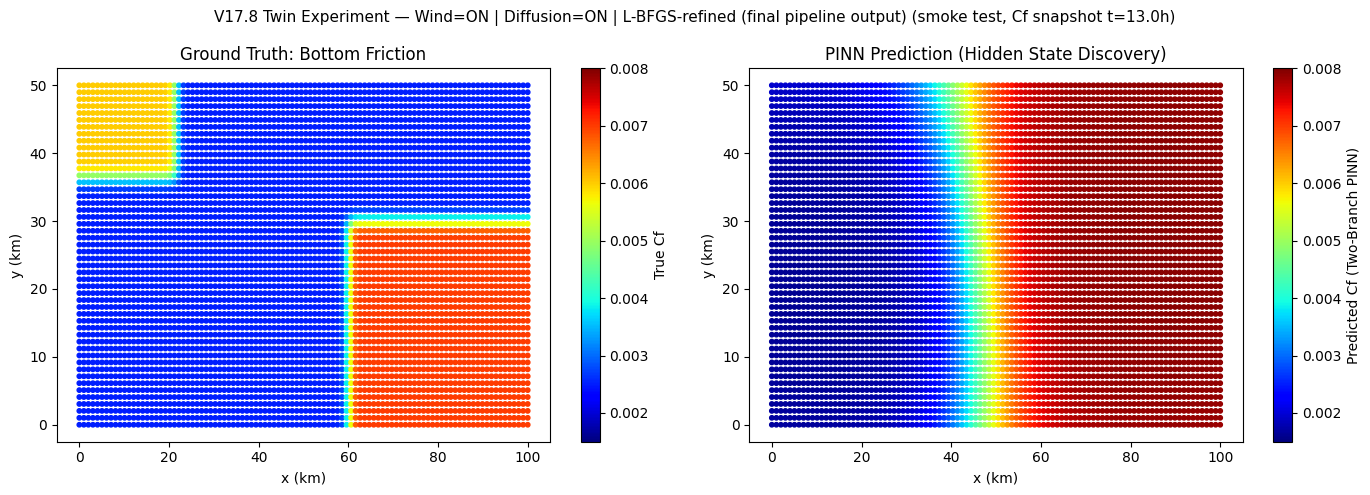


--- [Adam-only (pre-L-BFGS)] ---
    Evaluation window: t > 12.0h (post-spin-up), 59/72 snapshot(s) for u/v/h, 1 representative snapshot for Cf
🌊 Water Level (h) MAE: 0.3518 meters (Assimilated)
🚤 Long. Velocity (u) MAE: 1.2781 m/s (INFERRED - Hidden State)
🚤 Lat. Velocity (v) MAE: 0.6607 m/s (INFERRED - Hidden State)
🎯 H1a check (shallow water D<40m, n=120430 pts, post-spin-up trajectory): u=11.37% , v=12.08% of true velocity range [success criterion: < 15%]
🎯 Cf RMSE: 0.00280 (62.33% of true range) [success criterion §8.1: < 5%]
🎯 Cf spatial correlation r = 0.4356 [success criterion §8.1: r > 0.95]
🌀 Forcing-aliasing spatial fingerprint: corr(Cf_error, wind_x-pattern) = -0.037, corr(Cf_error, wind_y-pattern) = -0.671  [high |corr| under Wind=OFF => spatial aliasing signature; low |corr| under Wind=ON => aliasing resolved]

--- 📐 VB13 CHECK: L-BFGS-B effect on Cf RMSE (ground truth, not loss) ---
    Adam-only:      RMSE(Cf) = 62.33%, r(Cf) = 0.4356
    After L-BFGS-B: RMSE(Cf) = 65.

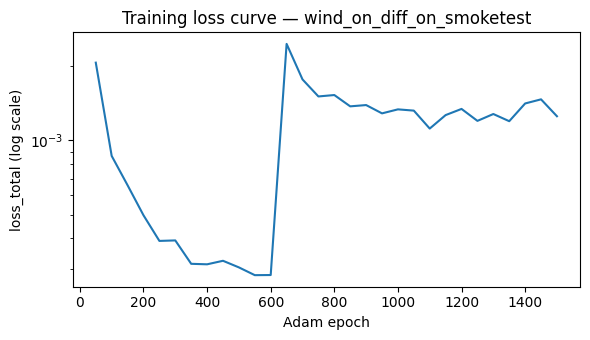

{'mae_h': np.float64(0.1888715080224584),
 'mae_u': np.float64(1.260814112697304),
 'mae_v': np.float64(0.5744710925567409),
 'mae_u_pct_shallow': np.float64(11.51742550076065),
 'mae_v_pct_shallow': np.float64(10.908052888738986),
 'rmse_cf_pct': np.float64(65.29241220200758),
 'r_cf': np.float64(0.42223138102723845),
 'corr_wind_x': -0.03740768062865929,
 'corr_wind_y': -0.6786174380502683,
 'corr_wind_combined': np.float64(0.6786174380502683),
 'n_eval_snapshots': 59,
 'case': 'Wind=ON | Diffusion=ON',
 'mode': 'smoke',
 'training_data_sparsified': True,
 'decoupled_collocation': True,
 'total_points_data': 57598,
 'total_points_physics': 360000,
 'training_seconds': 142.8933560848236,
 'lbfgs_seconds': 14228.757464170456,
 'peak_vram_mb': None}

In [9]:
# %%
# Cell 8: Evaluate & Visualize (V17.8 — RECONCILIATION RELEASE)
#
# 💥 V17.8 MERGES TWO INDEPENDENTLY-DEVELOPED V17.7 REWRITES OF THIS CELL (see
# CHANGELOG_V17_8.md for the full record):
#
#   - Lineage P (peer-review response): factored evaluation into a reusable
#     `_evaluate_checkpoint()` so the SAME logic could run against both the Adam-only and the
#     L-BFGS-refined checkpoint — closing the §9.4/VB13 gap that V17.6's Cell 8 had NO code path
#     to ever load the Adam-only weights. Added `_predict_chunked` for memory-bounded prediction
#     once evaluation stopped being a single small snapshot.
#   - Lineage D (independent review): independently found and fixed the SAME t=0-evaluation
#     bug, with a cleaner design — a `hidden_state_mask` spanning every post-spin-up snapshot for
#     u/v/h, and a SEPARATE, single-snapshot `cf_eval_mask` for Cf (since Cf is time-invariant by
#     construction, evaluating it at every snapshot would be redundant work returning identical
#     numbers). Also added an explicit `assert` guarding against a smoke-test run accidentally
#     writing into a canonical full-run ablation slot, and explicit MET/NOT-MET pass/fail
#     printing. Lineage D's Cell 8 never implemented the Adam-vs-L-BFGS comparison at all.
#
# This version keeps Lineage D's two-mask design and explicit guard/printing, and restores
# Lineage P's chunked prediction and Adam-vs-L-BFGS comparison via `_evaluate_checkpoint`.


def _predict_chunked(model_apply, params, t_norm_flat, x_norm_flat, y_norm_flat, chunk_size=100_000):
    """Memory-bounded forward pass over a (possibly large) flat array of normalized (t,x,y)
    points. Returns denormalized (h, u, v, Cf) as numpy arrays. Needed once the hidden-state
    evaluation mask covers every post-spin-up snapshot rather than one small slice."""
    vmap_apply = jax.vmap(model_apply, in_axes=(None, 0, 0, 0))
    n = t_norm_flat.shape[0]
    h_parts, u_parts, v_parts, cf_parts = [], [], [], []
    for lo in range(0, n, chunk_size):
        hi = min(lo + chunk_size, n)
        h_c, u_c, v_c, cf_c = vmap_apply(
            params,
            jnp.array(t_norm_flat[lo:hi], dtype=jnp.float64),
            jnp.array(x_norm_flat[lo:hi], dtype=jnp.float64),
            jnp.array(y_norm_flat[lo:hi], dtype=jnp.float64),
        )
        h_parts.append(np.array(h_c)); u_parts.append(np.array(u_c))
        v_parts.append(np.array(v_c)); cf_parts.append(np.array(cf_c))
    h_star = np.concatenate(h_parts); u_star = np.concatenate(u_parts)
    v_star = np.concatenate(v_parts); cf_star = np.concatenate(cf_parts)
    h_real, u_real, v_real, cf_real = utils_scaling.denormalize_outputs(h_star, u_star, v_star, cf_star)
    return np.array(h_real), np.array(u_real), np.array(v_real), np.array(cf_real)


def _pct_of_range(pred, true_at_eval, mask=None, range_source=None, range_mask=None):
    p, t = (pred[mask], true_at_eval[mask]) if mask is not None else (pred, true_at_eval)
    if p.size == 0:
        return np.nan
    if range_source is not None:
        rs = range_source[range_mask] if range_mask is not None else range_source
    else:
        rs = t
    rng = rs.max() - rs.min()
    return 100.0 * np.mean(np.abs(p - t)) / rng if rng > 0 else np.nan


def _evaluate_checkpoint(weights_path, model_apply, raw_data, label, case_label, do_plot):
    """Core evaluation for ONE saved checkpoint (Adam-only or L-BFGS-refined). Factored out
    (Lineage P) so the identical logic runs against both stages for the VB13 comparison."""
    try:
        with open(weights_path, 'rb') as f:
            params = pickle.load(f)
    except FileNotFoundError:
        return None

    x_raw, y_raw, t_raw = raw_data['x'], raw_data['y'], raw_data['t']
    h_true, u_true, v_true, Cf_true = raw_data['h'], raw_data['u'], raw_data['v'], raw_data['Cf_true']
    b_true_raw = raw_data['b_true']

    # --- Lineage D's two-mask design: full post-spin-up trajectory for u/v/h, ONE
    # representative post-spin-up snapshot for Cf (time-invariant by construction). ---
    all_times = np.unique(t_raw)
    post_spinup_times = all_times[all_times > config.SPINUP_DURATION_PHYSICAL]
    if post_spinup_times.size == 0:
        print(f"    ⚠️ No saved snapshot lies after SPINUP_DURATION_PHYSICAL="
              f"{config.SPINUP_DURATION_PHYSICAL/3600:.1f}h — falling back to the LAST saved "
              f"snapshot (results may include near-rest states).")
        eval_times = all_times[-1:]
    else:
        eval_times = post_spinup_times

    hidden_state_mask = np.isin(t_raw.flatten(), eval_times)
    cf_eval_mask = (t_raw == eval_times[0]).flatten()

    x_eval, y_eval, t_eval = x_raw[hidden_state_mask], y_raw[hidden_state_mask], t_raw[hidden_state_mask]
    x_norm, y_norm = utils_scaling.normalize_spatial(x_eval, y_eval)
    t_norm = utils_scaling.normalize_temporal(t_eval)

    # --- Lineage P's chunked prediction: memory-bounded, needed once this mask can span
    # tens or hundreds of thousands of rows (every post-spin-up snapshot, not one slice). ---
    h_pred, u_pred, v_pred, _ = _predict_chunked(
        model_apply, params, t_norm.flatten(), x_norm.flatten(), y_norm.flatten()
    )

    h_true_flat = h_true[hidden_state_mask].flatten()
    u_true_flat = u_true[hidden_state_mask].flatten()
    v_true_flat = v_true[hidden_state_mask].flatten()

    mae_h = np.mean(np.abs(h_pred - h_true_flat))
    mae_u = np.mean(np.abs(u_pred - u_true_flat))
    mae_v = np.mean(np.abs(v_pred - v_true_flat))

    D_true_flat = h_true_flat - b_true_raw[hidden_state_mask].flatten()
    shallow_mask = D_true_flat < 40.0
    n_shallow = int(shallow_mask.sum())

    u_true_full_flat = u_true.flatten()
    v_true_full_flat = v_true.flatten()
    D_true_full_flat = (h_true - b_true_raw).flatten()
    shallow_mask_full = D_true_full_flat < 40.0

    mae_u_pct_shallow = _pct_of_range(u_pred, u_true_flat, shallow_mask,
                                       range_source=u_true_full_flat, range_mask=shallow_mask_full)
    mae_v_pct_shallow = _pct_of_range(v_pred, v_true_flat, shallow_mask,
                                       range_source=v_true_full_flat, range_mask=shallow_mask_full)

    # --- Cf: single representative snapshot, small — no chunking needed. ---
    x_cf, y_cf = x_raw[cf_eval_mask], y_raw[cf_eval_mask]
    x_cf_norm, y_cf_norm = utils_scaling.normalize_spatial(x_cf, y_cf)
    t_cf_norm = utils_scaling.normalize_temporal(t_raw[cf_eval_mask])
    _, _, _, Cf_pred = _predict_chunked(
        model_apply, params, t_cf_norm.flatten(), x_cf_norm.flatten(), y_cf_norm.flatten()
    )

    cf_true_flat = Cf_true[cf_eval_mask].flatten()
    cf_range = cf_true_flat.max() - cf_true_flat.min()
    rmse_cf = np.sqrt(np.mean((Cf_pred - cf_true_flat) ** 2))
    rmse_cf_pct = 100.0 * rmse_cf / cf_range if cf_range > 0 else np.nan
    r_cf = np.corrcoef(Cf_pred, cf_true_flat)[0, 1]

    cf_error_flat = Cf_pred - cf_true_flat
    wind_pattern_x = np.sin(np.pi * y_cf.flatten() / (config.L_REF / 2.0))
    wind_pattern_y = np.cos(np.pi * x_cf.flatten() / config.L_REF)
    if np.std(cf_error_flat) > 0:
        corr_wind_x = float(np.corrcoef(cf_error_flat, wind_pattern_x)[0, 1])
        corr_wind_y = float(np.corrcoef(cf_error_flat, wind_pattern_y)[0, 1])
    else:
        corr_wind_x, corr_wind_y = np.nan, np.nan
    corr_wind_combined = (np.nanmax([abs(corr_wind_x), abs(corr_wind_y)])
                           if not (np.isnan(corr_wind_x) and np.isnan(corr_wind_y)) else np.nan)

    print(f"\n--- [{label}] ---")
    print(f"    Evaluation window: t > {config.SPINUP_DURATION_PHYSICAL/3600:.1f}h (post-spin-up), "
          f"{eval_times.size}/{all_times.size} snapshot(s) for u/v/h, "
          f"1 representative snapshot for Cf")
    print(f"🌊 Water Level (h) MAE: {mae_h:.4f} meters (Assimilated)")
    print(f"🚤 Long. Velocity (u) MAE: {mae_u:.4f} m/s (INFERRED - Hidden State)")
    print(f"🚤 Lat. Velocity (v) MAE: {mae_v:.4f} m/s (INFERRED - Hidden State)")
    if n_shallow > 0:
        print(f"🎯 H1a check (shallow water D<40m, n={n_shallow} pts, post-spin-up trajectory): "
              f"u={mae_u_pct_shallow:.2f}% , v={mae_v_pct_shallow:.2f}% of true velocity range "
              f"[success criterion: < 15%]")
    else:
        print("🎯 H1a check: no evaluation points with D<40m in this dataset — cannot assess.")
    print(f"🎯 Cf RMSE: {rmse_cf:.5f} ({rmse_cf_pct:.2f}% of true range) "
          f"[success criterion §8.1: < 5%]")
    print(f"🎯 Cf spatial correlation r = {r_cf:.4f} [success criterion §8.1: r > 0.95]")
    print(f"🌀 Forcing-aliasing spatial fingerprint: corr(Cf_error, wind_x-pattern) = {corr_wind_x:.3f}, "
          f"corr(Cf_error, wind_y-pattern) = {corr_wind_y:.3f}  "
          f"[high |corr| under Wind=OFF => spatial aliasing signature; "
          f"low |corr| under Wind=ON => aliasing resolved]")

    if do_plot:
        plt.figure(figsize=(14, 5))
        plt.suptitle(f"V17.8 Twin Experiment — {case_label} | {label} "
                     f"({'smoke test' if config.SMOKE_TEST else 'full run'}, "
                     f"Cf snapshot t={float(eval_times[0])/3600:.1f}h)", fontsize=11)

        plt.subplot(1, 2, 1)
        sc1 = plt.scatter(x_cf.flatten()/1000, y_cf.flatten()/1000,
                           c=cf_true_flat, cmap='jet', s=10,
                           vmin=config.CF_MIN, vmax=config.CF_MIN + config.CF_RANGE)
        plt.colorbar(sc1, label='True Cf')
        plt.title("Ground Truth: Bottom Friction")
        plt.xlabel("x (km)"); plt.ylabel("y (km)")

        plt.subplot(1, 2, 2)
        sc2 = plt.scatter(x_cf.flatten()/1000, y_cf.flatten()/1000,
                           c=Cf_pred, cmap='jet', s=10,
                           vmin=config.CF_MIN, vmax=config.CF_MIN + config.CF_RANGE)
        plt.colorbar(sc2, label='Predicted Cf (Two-Branch PINN)')
        plt.title("PINN Prediction (Hidden State Discovery)")
        plt.xlabel("x (km)"); plt.ylabel("y (km)")

        plt.tight_layout()
        plt.show()

    return {"mae_h": mae_h, "mae_u": mae_u, "mae_v": mae_v,
            "mae_u_pct_shallow": mae_u_pct_shallow, "mae_v_pct_shallow": mae_v_pct_shallow,
            "rmse_cf_pct": rmse_cf_pct, "r_cf": r_cf,
            "corr_wind_x": corr_wind_x, "corr_wind_y": corr_wind_y,
            "corr_wind_combined": corr_wind_combined,
            "n_eval_snapshots": int(eval_times.size)}


def evaluate_model():
    print("\n--- 🔬 INITIATING KINEMATIC VALIDATION (Hidden State Discovery, V17.8) ---")
    tag = config.scenario_tag()
    rid = config.run_id()
    case_label = f"Wind={'ON' if config.ENABLE_WIND else 'OFF'} | Diffusion={'ON' if config.ENABLE_DIFFUSION else 'OFF'}"
    print(f"    Ablation case: {case_label}  (tag: {tag}, mode: {'smoke' if config.SMOKE_TEST else 'full'}, run_id: {rid})")

    # --- Lineage D: explicit guard against a smoke-test run corrupting a canonical full-run
    # ablation slot. Previously this separation relied only on run_id's naming convention. ---
    canonical_tags_guard = ["wind_off_diff_off", "wind_on_diff_off", "wind_on_diff_on"]
    assert not (config.SMOKE_TEST and rid in canonical_tags_guard), (
        f"SMOKE_TEST=True but run_id '{rid}' matches a canonical full-run tag — refusing to "
        f"store this result, as it would corrupt the ablation comparison."
    )

    model_init, model_apply = init_and_apply_model()
    lbfgs_path = f'data/pinn_lbfgs_weights_v17_{rid}.pkl'
    if not os.path.exists(lbfgs_path):
        print(f"❌ Weights not found at {lbfgs_path}. Run Cells 6 and 7 with the same "
              f"config.ENABLE_WIND / config.ENABLE_DIFFUSION / config.SMOKE_TEST settings first.")
        return

    raw_data = np.load(config.DATA_PATH)

    gen_version = str(raw_data['generator_version'][0]) if 'generator_version' in raw_data else None
    if gen_version is not None and gen_version != 'V17.8_reconciled':
        print(f"    ⚠️ WARNING: {config.DATA_PATH} was generated by tag {gen_version!r}, not "
              f"this version's Cell 3. If this tag predates the advection-instability fix "
              f"(V17.6-or-earlier — see Cell 4's _PRE_UPWIND_FIX_TAGS), the ground truth "
              f"itself is untrustworthy regardless of anything below. Regenerate via this "
              f"version's Cell 3 before trusting §8.1 numbers.")

    sparsified = bool(raw_data['satellite_sparsification_enabled'][0]) if 'satellite_sparsification_enabled' in raw_data else None
    if sparsified is not None:
        print(f"    🛰️  Training DATA pool for this run was "
              f"{'SATELLITE-SPARSIFIED (stylized proxy — see Cell 3)' if sparsified else 'DENSE (sparsification OFF)'}. "
              f"Evaluation below is always against the full dense grid regardless.")

    history_path_early = f'data/training_history_v17_{rid}.pkl'
    decoupled_collocation, total_points_data, total_points_physics = None, None, None
    if os.path.exists(history_path_early):
        with open(history_path_early, 'rb') as f:
            _hp_early = pickle.load(f)
        decoupled_collocation = _hp_early.get('decoupled_collocation')
        total_points_data = _hp_early.get('total_points_data')
        total_points_physics = _hp_early.get('total_points_physics')
        if decoupled_collocation is not None:
            print(f"    🧩 Physics-collocation design used in training: "
                  f"{'DECOUPLED, full-domain (default)' if decoupled_collocation else 'COUPLED to satellite mask (pre-fix — physics under-enforced away from the satellite footprint)'} "
                  f"| data points={total_points_data}, physics points={total_points_physics}")

    # --- Primary result: the final pipeline output (L-BFGS-refined weights). ---
    result = _evaluate_checkpoint(lbfgs_path, model_apply, raw_data,
                                   label="L-BFGS-refined (final pipeline output)",
                                   case_label=case_label, do_plot=True)

    # --- Lineage P: explicit Adam-only-vs-L-BFGS comparison, per §9.4/VB13's commitment.
    # Lineage D's Cell 8 had no equivalent — this closes that gap in the merged version. ---
    if getattr(config, 'EVALUATE_ADAM_STAGE_SEPARATELY', False):
        adam_path = f'data/pinn_adam_weights_v17_{rid}.pkl'
        result_adam = _evaluate_checkpoint(adam_path, model_apply, raw_data,
                                            label="Adam-only (pre-L-BFGS)",
                                            case_label=case_label, do_plot=False)
        if result_adam is not None:
            d_rmse = result["rmse_cf_pct"] - result_adam["rmse_cf_pct"]
            print(f"\n--- 📐 VB13 CHECK: L-BFGS-B effect on Cf RMSE (ground truth, not loss) ---")
            print(f"    Adam-only:      RMSE(Cf) = {result_adam['rmse_cf_pct']:.2f}%, r(Cf) = {result_adam['r_cf']:.4f}")
            print(f"    After L-BFGS-B: RMSE(Cf) = {result['rmse_cf_pct']:.2f}%, r(Cf) = {result['r_cf']:.4f}")
            if d_rmse > 5.0:
                print(f"    🚨 L-BFGS-B WORSENED RMSE(Cf) by {d_rmse:.2f} percentage points — "
                      f"consistent with the Radfar (2026) pathology cited in §9.4/VB13. Per the "
                      f"proposal's own decision rule, the ADAM-ONLY checkpoint should be treated "
                      f"as the primary reported result for this scenario.")
            elif d_rmse > 0:
                print(f"    ⚠️ L-BFGS-B mildly worsened RMSE(Cf) by {d_rmse:.2f} points — within "
                      f"noise for a single run, but worth checking across ensemble members "
                      f"(Phase 3) before treating L-BFGS-B as unconditionally safe.")
            else:
                print(f"    ✅ L-BFGS-B improved (or did not worsen) RMSE(Cf) by "
                      f"{abs(d_rmse):.2f} percentage points for this run.")
        else:
            print(f"\n    ℹ️ Adam-only weights not found at {adam_path} — skipping the VB13 "
                  f"before/after comparison for this run.")

    # --- Lineage D: explicit MET/NOT-MET pass/fail statement for the primary result. ---
    criteria_met = (result["rmse_cf_pct"] < 5.0 and result["r_cf"] > 0.95)
    is_full_model = (tag == "wind_on_diff_on")
    if criteria_met:
        print("\n   ✅ Success criteria MET for this ablation case.")
    elif is_full_model:
        print("\n   ⚠️ Success criteria NOT met on the FULL model (wind ON, diffusion ON).")
    else:
        print("\n   ℹ️ Success criteria NOT met — expected for this partial ablation case.")

    if config.SMOKE_TEST:
        print("\n   ℹ️ SMOKE-TEST MODE: these numbers assess pipeline health only (short "
              "duration, reduced epochs) — they are NOT valid for §8.1 scenario comparison. "
              "Re-run with config.SMOKE_TEST=False for numbers that count.")

    history_path = f'data/training_history_v17_{rid}.pkl'
    training_seconds, peak_vram_mb, lbfgs_seconds, loss_history = None, None, None, None
    if os.path.exists(history_path):
        with open(history_path, 'rb') as f:
            history_payload = pickle.load(f)
        training_seconds = history_payload.get('training_seconds')
        peak_vram_mb = history_payload.get('peak_vram_mb')
        lbfgs_seconds = history_payload.get('lbfgs_seconds')
        loss_history = history_payload.get('loss_history')
        decoupled_collocation = history_payload.get('decoupled_collocation', decoupled_collocation)
        total_points_data = history_payload.get('total_points_data', total_points_data)
        total_points_physics = history_payload.get('total_points_physics', total_points_physics)

        if training_seconds is not None and lbfgs_seconds is not None:
            total_seconds = (training_seconds or 0) + (lbfgs_seconds or 0)
            vram_str = f"{peak_vram_mb:.0f} MB" if peak_vram_mb is not None else "unavailable"
            print(f"\n⏱️  Cost: Adam={training_seconds:.1f}s, L-BFGS={lbfgs_seconds:.1f}s, "
                  f"total={total_seconds:.1f}s, peak VRAM={vram_str}")
        else:
            print("\n⏱️  Cost: partial data only in training-history file.")

        if loss_history:
            epochs_arr = [pt['epoch'] for pt in loss_history]
            loss_arr = [pt['loss_total'] for pt in loss_history]
            plt.figure(figsize=(6, 3.5))
            plt.plot(epochs_arr, loss_arr)
            plt.yscale('log')
            plt.xlabel("Adam epoch")
            plt.ylabel("loss_total (log scale)")
            plt.title(f"Training loss curve — {rid}")
            plt.tight_layout()
            plt.show()
    else:
        print(f"\n⏱️  No training-history file found at {history_path} "
              f"(Cell 6 wasn't run under this exact run_id) — cost/loss-curve skipped.")

    result.update({"case": case_label, "mode": "smoke" if config.SMOKE_TEST else "full",
                    "training_data_sparsified": sparsified,
                    "decoupled_collocation": decoupled_collocation,
                    "total_points_data": total_points_data,
                    "total_points_physics": total_points_physics,
                    "training_seconds": training_seconds, "lbfgs_seconds": lbfgs_seconds,
                    "peak_vram_mb": peak_vram_mb})

    results_path = 'data/ablation_results_v17.pkl'
    all_results = {}
    if os.path.exists(results_path):
        with open(results_path, 'rb') as f:
            all_results = pickle.load(f)
    all_results[rid] = result
    with open(results_path, 'wb') as f:
        pickle.dump(all_results, f)

    canonical_tags = ["wind_off_diff_off", "wind_on_diff_off", "wind_on_diff_on"]  # full-run only
    if any(t in all_results for t in canonical_tags):
        print("\n--- 📊 ABLATION COMPARISON (§8.1, FULL RUNS ONLY — smoke tests excluded) ---")
        header = (f"{'Scenario':<20}{'RMSE(Cf) %':>12}{'r(Cf)':>10}{'MAE h':>10}{'MAE u':>10}"
                  f"{'MAE v':>10}{'Corr(err,W)':>13}{'Pass?':>8}{'Time(s)':>10}{'VRAM(MB)':>10}{'Colloc':>10}")
        print(header)
        print("-" * len(header))
        for t in canonical_tags:
            if t in all_results:
                r = all_results[t]
                passed = "✅" if (r['rmse_cf_pct'] < 5.0 and r['r_cf'] > 0.95) else "⚠️"
                ts = r.get('training_seconds')
                ls = r.get('lbfgs_seconds')
                total_t = f"{(ts or 0)+(ls or 0):.0f}" if (ts is not None or ls is not None) else "—"
                vram = f"{r['peak_vram_mb']:.0f}" if r.get('peak_vram_mb') is not None else "—"
                cwc = r.get('corr_wind_combined')
                corr_str = f"{cwc:.3f}" if cwc is not None and not np.isnan(cwc) else "—"
                dc = r.get('decoupled_collocation')
                colloc_str = "decoup." if dc is True else ("coupled" if dc is False else "—")
                print(f"{t:<20}{r['rmse_cf_pct']:>12.2f}{r['r_cf']:>10.3f}"
                      f"{r['mae_h']:>10.4f}{r['mae_u']:>10.4f}{r['mae_v']:>10.4f}"
                      f"{corr_str:>13}{passed:>8}{total_t:>10}{vram:>10}{colloc_str:>10}")
            else:
                print(f"{t:<20}{'— not run yet —':>93}")

        colloc_flags = [all_results[t].get('decoupled_collocation') for t in canonical_tags if t in all_results]
        if len(set(colloc_flags)) > 1:
            print("\n   ⚠️ WARNING: the three scenarios above were NOT all trained under the same "
                  "collocation design (decoupled vs. coupled) — this table is comparing results "
                  "from different optimization problems.")

        if all(t in all_results for t in canonical_tags):
            delta = all_results["wind_off_diff_off"]["rmse_cf_pct"] - all_results["wind_on_diff_on"]["rmse_cf_pct"]
            if delta > 0:
                print(f"\n   🎯 Forcing-aliasing evidence (amplitude): RMSE(Cf) improved by {delta:.2f} "
                      f"percentage points from wind-off to the full V17 model.")
            elif delta < 0:
                print(f"\n   ⚠️ RMSE(Cf) got WORSE by {abs(delta):.2f} percentage points from "
                      f"wind-off to the full V17 model — investigate before final reporting.")
            else:
                print(f"\n   • RMSE(Cf) showed no change from wind-off to the full V17 model.")

            corr_off = all_results["wind_off_diff_off"].get("corr_wind_combined")
            corr_on = all_results["wind_on_diff_on"].get("corr_wind_combined")
            if corr_off is not None and corr_on is not None and not (np.isnan(corr_off) or np.isnan(corr_on)):
                verdict = "Consistent with aliasing being resolved." if corr_on < corr_off else "Does NOT show the expected reduction — investigate."
                print(f"   🌀 Forcing-aliasing evidence (spatial fingerprint): |corr(err,wind)| = "
                      f"{corr_off:.3f} (wind-off) -> {corr_on:.3f} (full model). {verdict}")

    return result

evaluate_model()